# Análisis estadístico y predictivo de la Premier League 2022-2023
**Autor: Brais Muiño Otero**

---

## Índice

A continuación se presenta la estructura del proyecto:

1. **Introducción**
   - 1.1. Contexto del problema
   - 1.2. Objetivos del trabajo
   - 1.3. Descripción del dataset
2. **Carga y preparación de los datos**
   - 2.1. Importación de librerías y carga del dataset
   - 2.2. Inspección inicial del dataset
   - 2.3. Comprobación de valores perdidos
   - 2.4. Conversión de variables
   - 2.5. Creación de variables derivadas
3. **¿Cómo se juega en la Premier League?**
   - 3.1. Distribución de goles
   - 3.2. Distribución de resultados
   - 3.3. Comparación entre equipo local y visitante
   - 3.4. Relación entre variables ofensivas y goles
   - 3.5. Correlaciones entre variables numéricas
4. **¿Existe realmente la ventaja de jugar en casa?**
   - 4.1. Intervalo de confianza para la media de goles locales
   - 4.2. Contraste de medias: goles local vs visitante
   - 4.3. Contraste de medias: tiros a puerta local vs visitante
   - 4.4. Test Chi-cuadrado: tarjetas rojas vs resultado
5. **¿Cuánto de bueno es cada equipo realmente?**
   - 5.1. Modelo Dixon-Coles: estimación por máxima verosimilitud
   - 5.2. Ranking de fuerza de ataque y debilidad defensiva
   - 5.3. Comparación con la clasificación real
6. **¿Quién habría ganado la liga en otras circunstancias?**
   - 6.1. Simulación Monte Carlo de la temporada (10.000 iteraciones)
   - 6.2. Probabilidades de campeón, top 4 y descenso
   - 6.3. Separando calidad de fortuna
7. **¿Se puede predecir el resultado de un partido?**
   - 7.1. Preparación y división de datos
   - 7.2. Regresión de Poisson: predicción de goles
      - 7.2.1. Modelo de Poisson y medidas de bondad de ajuste
      - 7.2.2. Ejemplos de predicción de goles
      - 7.2.3. Diagnosis del modelo y validación por supuestos
   - 7.3. Regresión logística binomial: predicción de victoria local
      - 7.3.1. Modelo logístico y medidas de bondad de ajuste
      - 7.3.2. Ejemplos de predicción e interpretación de Odds Ratios
      - 7.3.3. Diagnosis del modelo y validation por supuestos
8. **¿Qué patrones de juego existen entre equipos?**
   - 8.1. Reducción de dimensionalidad mediante PCA
   - 8.2. Identificación de grupos mediante K-means
   - 8.3. Interpretación táctica de los clusters
9. **¿Cómo optimizar el rendimiento de un equipo?**
   - 9.1. Planteamiento del problema y función objetivo
   - 9.2. Restricciones y resolución del modelo lineal
   - 9.3. Análisis de sensibilidad
   - 9.4. Interpretación de resultados
10. **Conclusiones**
    - 10.1. Principales hallazgos
    - 10.2. Limitaciones
    - 10.3. Líneas futuras

---
## 1. Introducción

### 1.1. Contexto del problema

El fútbol es uno de los deportes con mayor impacto a nivel mundial, y en los últimos años el análisis de datos ha adquirido un papel fundamental en la comprensión del juego. Gracias al desarrollo de herramientas estadísticas y técnicas de aprendizaje automático, es posible analizar el rendimiento de los equipos, identificar patrones de juego y estudiar los factores que influyen en el resultado de los partidos.

En este contexto, el análisis de datos deportivos permite transformar información cuantitativa en conocimiento útil, tanto para la toma de decisiones como para la interpretación del juego desde una perspectiva más objetiva. Variables como el número de goles, tiros, tiros a puerta, corners o tarjetas ofrecen una descripción detallada del desarrollo de cada partido.

El presente trabajo se centra en el análisis de una temporada de la Premier League inglesa, una de las competiciones más importantes del fútbol internacional, utilizando técnicas de estadística y ciencia de datos.

### 1.2. Objetivos del trabajo

El objetivo principal de este estudio es analizar estadísticamente los partidos de la temporada 2022-2023 de la Premier League, así como aplicar diferentes técnicas de modelización para comprender mejor los factores que influyen en el resultado de los encuentros. De forma más concreta, los objetivos del trabajo son:

- Realizar un análisis exploratorio de las variables más relevantes del dataset.
- Estudiar la distribución de los goles y los resultados de los partidos.
- Analizar la relación entre variables ofensivas y el rendimiento de los equipos.
- Aplicar técnicas de inferencia estadística para validar hipótesis.
- Estimar la fuerza de ataque y debilidad defensiva de cada equipo mediante el modelo Dixon-Coles.
- Simular la temporada mediante métodos de Monte Carlo para cuantificar el papel de la suerte en la clasificación final.
- Aplicar métodos de clasificación supervisada, como regresión logística, LDA y KNN, para predecir resultados.
- Utilizar métodos de reducción de dimensionalidad, como el análisis de componentes principales (PCA).
- Identificar patrones de juego mediante técnicas de clustering (K-means).
- Plantear un problema de optimización lineal en el contexto deportivo.

### 1.3. Descripción del dataset

El conjunto de datos utilizado en este trabajo corresponde a la temporada 2022-2023 de la Premier League inglesa. Cada fila del dataset representa un partido, mientras que las columnas contienen información sobre diferentes aspectos del mismo.

Entre las variables más relevantes se encuentran:

- **FTHG**: número de goles marcados por el equipo local.
- **FTAG**: número de goles marcados por el equipo visitante.
- **FTR**: resultado final del partido (H = victoria local, D = empate, A = victoria visitante).
- **HS / AS**: número total de tiros realizados por cada equipo.
- **HST / AST**: número de tiros a puerta.
- **HC / AC**: número de saques de esquina.
- **HF / AF**: número de faltas cometidas.
- **HY / AY**: número de tarjetas amarillas.
- **HR / AR**: número de tarjetas rojas.

El tamaño del dataset, con aproximadamente 380 partidos, lo hace adecuado para aplicar técnicas de análisis estadístico y aprendizaje automático sin que el volumen de datos resulte excesivo.

---
## 2. Carga y preparación de los datos

### 2.1. Importación de librerías y carga del dataset

En esta sección se importan las librerías necesarias para todo el análisis (celda siguiente) y se carga el conjunto de datos de la temporada 2022-2023 de la Premier League inglesa. Centralizar las dependencias al inicio favorece la reproducibilidad del estudio.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.optimize import minimize
from scipy.stats import poisson, ttest_ind, ttest_1samp, chi2_contingency
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import statsmodels.api as sm
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 6)
sns.set_theme(style='whitegrid')

print("Librerías cargadas correctamente")

Librerías cargadas correctamente


In [2]:
# Carga del dataset (equivalente a read.csv en R)
datos = pd.read_csv('epl_results_2022-23.csv')

# Primeras 10 filas (equivalente a head(datos, 10))
datos.head(10)

,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,...,HST,AST,HF,AF,HC,AC,HY,AY,HR,AR
0,05/08/2022,20:00,Crystal Palace,Arsenal,0,2,A,0,1,A,...,2,2,16,11,3,5,1,2,0,0
1,06/08/2022,12:30,Fulham,Liverpool,2,2,D,1,0,H,...,3,4,7,9,4,4,2,0,0,0
2,06/08/2022,15:00,Bournemouth,Aston Villa,2,0,H,1,0,H,...,3,2,18,16,5,5,3,3,0,0
3,06/08/2022,15:00,Leeds,Wolves,2,1,H,1,1,D,...,4,6,13,9,6,4,2,0,0,0
4,06/08/2022,15:00,Newcastle,Nottingham,2,0,H,0,0,D,...,10,0,9,14,11,1,0,3,0,0
5,06/08/2022,15:00,Tottenham,Southampton,4,1,H,2,1,H,...,8,2,11,6,10,2,3,0,0,0
6,06/08/2022,17:30,Everton,Chelsea,0,1,A,0,1,A,...,4,6,14,11,4,16,3,2,0,0
7,07/08/2022,14:00,Leicester,Brentford,2,2,D,1,0,H,...,5,3,6,5,5,6,0,0,0,0
8,07/08/2022,14:00,Man United,Brighton,1,2,A,0,2,A,...,5,4,7,12,6,2,4,1,0,0
9,07/08/2022,16:30,West Ham,Man City,0,2,A,0,1,A,...,1,2,8,4,1,4,0,1,0,0


### 2.2. Inspección inicial del dataset

Se realiza una exploración inicial del dataset con el objetivo de conocer su estructura, número de observaciones, variables disponibles y tipos de datos.

In [3]:
# Dimensión del dataset (equivalente a dim() en R)
print(f"Dimensión: {datos.shape}  →  {datos.shape[0]} filas, {datos.shape[1]} columnas")

# Nombres de columnas (equivalente a colnames() en R)
print("\nColumnas:", datos.columns.tolist())

# Estructura del dataset (equivalente a str() en R)
print("\nEstructura:")
datos.info()

# Resumen estadístico (equivalente a summary() en R)
datos.describe()

Dimensión: (380, 23)  →  380 filas, 23 columnas

Columnas: ['Date', 'Time', 'HomeTeam', 'AwayTeam', 'FTHG', 'FTAG', 'FTR', 'HTHG', 'HTAG', 'HTR', 'Referee', 'HS', 'AS', 'HST', 'AST', 'HF', 'AF', 'HC', 'AC', 'HY', 'AY', 'HR', 'AR']

Estructura:
<class 'pandas.DataFrame'>
RangeIndex: 380 entries, 0 to 379
Data columns (total 23 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Date      380 non-null    str  
 1   Time      380 non-null    str  
 2   HomeTeam  380 non-null    str  
 3   AwayTeam  380 non-null    str  
 4   FTHG      380 non-null    int64
 5   FTAG      380 non-null    int64
 6   FTR       380 non-null    str  
 7   HTHG      380 non-null    int64
 8   HTAG      380 non-null    int64
 9   HTR       380 non-null    str  
 10  Referee   380 non-null    str  
 11  HS        380 non-null    int64
 12  AS        380 non-null    int64
 13  HST       380 non-null    int64
 14  AST       380 non-null    int64
 15  HF        380 non-null    in

,FTHG,FTAG,HTHG,HTAG,HS,AS,HST,AST,HF,AF,HC,AC,HY,AY,HR,AR
count,380.000000,380.000000,380.000000,380.000000,380.000000,380.000000,380.000000,380.000000,380.000000,380.000000,380.000000,380.000000,380.000000,380.000000,380.000000,380.000000
mean,1.634211,1.218421,0.757895,0.563158,13.952632,11.310526,4.907895,3.894737,10.597368,10.931579,5.636842,4.471053,1.671053,1.915789,0.047368,0.026316
std,1.419944,1.183518,0.918480,0.746998,5.604170,4.941173,2.495260,2.230627,3.288020,3.463424,3.073370,2.817530,1.249677,1.358357,0.224768,0.160284
min,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,0.000000,0.000000,10.000000,8.000000,3.000000,2.000000,8.000000,8.000000,3.000000,2.000000,1.000000,1.000000,0.000000,0.000000
50%,1.000000,1.000000,1.000000,0.000000,14.000000,11.000000,5.000000,4.000000,10.000000,11.000000,5.000000,4.000000,2.000000,2.000000,0.000000,0.000000
75%,2.000000,2.000000,1.000000,1.000000,17.000000,15.000000,7.000000,5.000000,13.000000,13.000000,8.000000,6.000000,3.000000,3.000000,0.000000,0.000000
max,9.000000,6.000000,5.000000,3.000000,33.000000,30.000000,15.000000,11.000000,23.000000,24.000000,17.000000,19.000000,6.000000,7.000000,2.000000,1.000000


A partir de la inspección inicial del dataset, se observa que el conjunto de datos está compuesto por 380 observaciones y 23 variables, lo que corresponde al número total de partidos disputados en una temporada completa de la Premier League.

Las variables incluyen información tanto categórica como numérica. En particular, variables como `HomeTeam`, `AwayTeam`, `Referee` y `FTR` son de tipo categórico, mientras que variables como `FTHG`, `FTAG`, `HS`, `HST`, `HC` o `HY` son de tipo numérico y representan estadísticas del partido.

El resumen estadístico de las variables numéricas permite extraer varias conclusiones relevantes:

- El número medio de goles del equipo local (1.63) es superior al del equipo visitante (1.22), lo que sugiere la existencia de ventaja de jugar en casa.
- Los equipos locales realizan, en promedio, más tiros (13.95 frente a 11.31) y más tiros a puerta (4.91 frente a 3.90), lo que refuerza la idea de un mayor dominio ofensivo del equipo local.
- En cuanto a las faltas y tarjetas, ambos equipos presentan valores similares, aunque los equipos visitantes reciben ligeramente más tarjetas amarillas en promedio.
- Las tarjetas rojas son poco frecuentes, con valores medios cercanos a cero, lo que indica que son eventos poco habituales en los partidos.

### 2.3. Comprobación de valores perdidos

En esta sección se analiza la presencia de valores perdidos en el conjunto de datos, ya que estos pueden afectar al análisis estadístico y a la construcción de modelos. La detección y tratamiento adecuado de los valores nulos es un paso fundamental en cualquier proceso de análisis de datos, garantizando la consistencia y fiabilidad de los resultados.

In [4]:
# Total de valores perdidos (equivalente a sum(is.na(datos)) en R)
print(f"Total valores perdidos: {datos.isna().sum().sum()}")

# Por columna (equivalente a colSums(is.na(datos)) en R)
print("\nValores perdidos por variable:")
print(datos.isna().sum())

Total valores perdidos: 0

Valores perdidos por variable:
Date        0
Time        0
HomeTeam    0
AwayTeam    0
FTHG        0
FTAG        0
FTR         0
HTHG        0
HTAG        0
HTR         0
Referee     0
HS          0
AS          0
HST         0
AST         0
HF          0
AF          0
HC          0
AC          0
HY          0
AY          0
HR          0
AR          0
dtype: int64


No se detectan valores perdidos (nulos) en ninguna de las variables, por lo que no es necesario realizar ningún tratamiento adicional, facilitando positivamente el análisis posterior.

### 2.4. Conversión de variables

En esta sección se realiza la conversión de las variables del dataset a los tipos de datos adecuados, con el objetivo de garantizar un correcto análisis posterior. En particular, se transforman las variables categóricas a tipo `category` y la variable de fecha a un formato apropiado, lo que permite su correcta utilización en métodos estadísticos y modelos de aprendizaje automático.

In [5]:
# Conversión de variables categóricas (equivalente a as.factor() en R)
datos['HomeTeam'] = datos['HomeTeam'].astype('category')
datos['AwayTeam'] = datos['AwayTeam'].astype('category')
datos['Referee']  = datos['Referee'].astype('category')
datos['FTR']      = datos['FTR'].astype('category')
datos['HTR']      = datos['HTR'].astype('category')

# Conversión de fecha (equivalente a as.Date() en R)
datos['Date'] = pd.to_datetime(datos['Date'], format='%d/%m/%Y')

datos.dtypes

Date        datetime64[us]
Time                   str
HomeTeam          category
AwayTeam          category
FTHG                 int64
FTAG                 int64
FTR               category
HTHG                 int64
HTAG                 int64
HTR               category
Referee           category
HS                   int64
AS                   int64
HST                  int64
AST                  int64
HF                   int64
AF                   int64
HC                   int64
AC                   int64
HY                   int64
AY                   int64
HR                   int64
AR                   int64
dtype: object

Las variables categóricas se han convertido a tipo `category` y la variable `Date` a formato fecha, lo que permite su correcto tratamiento en el análisis estadístico y en la construcción de modelos.

### 2.5. Creación de variables derivadas

En esta sección se crean nuevas variables a partir de las ya existentes con el objetivo de enriquecer el análisis y facilitar la construcción de modelos. Estas variables derivadas permiten capturar información relevante, como el número total de goles o la clasificación de los partidos según su resultado, mejorando así la capacidad explicativa del dataset.

In [6]:
datos['TotalGoals']      = datos['FTHG'] + datos['FTAG']
datos['HomeWin']         = (datos['FTR'] == 'H').astype(int)
datos['Over2_5']         = (datos['TotalGoals'] > 2.5).astype(int)
datos['GoalDiff']        = datos['FTHG'] - datos['FTAG']
datos['ShotsDiff']       = datos['HS']  - datos['AS']
datos['ShotsTargetDiff'] = datos['HST'] - datos['AST']

# Eficiencia ofensiva (goles / tiros a puerta)
# Equivalente a ifelse(HST > 0, FTHG/HST, 0) en R
datos['EfficiencyHome'] = np.where(datos['HST'] > 0, datos['FTHG'] / datos['HST'], 0)
datos['EfficiencyAway'] = np.where(datos['AST'] > 0, datos['FTAG'] / datos['AST'], 0)
datos['EfficiencyDiff'] = datos['EfficiencyHome'] - datos['EfficiencyAway']

# Precisión (tiros a puerta / tiros totales)
datos['PrecisionHome'] = np.where(datos['HS'] > 0, datos['HST'] / datos['HS'], 0)
datos['PrecisionAway'] = np.where(datos['AS'] > 0, datos['AST'] / datos['AS'], 0)

datos['TotalShots']    = datos['HS'] + datos['AS']
datos['ShotRatioHome'] = np.where(datos['TotalShots'] > 0, datos['HS'] / datos['TotalShots'], 0)

print(f"Dataset enriquecido: {datos.shape[0]} filas, {datos.shape[1]} columnas")
datos.head(3)

Dataset enriquecido: 380 filas, 36 columnas


,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,...,GoalDiff,ShotsDiff,ShotsTargetDiff,EfficiencyHome,EfficiencyAway,EfficiencyDiff,PrecisionHome,PrecisionAway,TotalShots,ShotRatioHome
0,2022-08-05,20:00,Crystal Palace,Arsenal,0,2,A,0,1,A,...,-2,0,0,0.000000,1.0,-1.000000,0.200000,0.200000,20,0.500000
1,2022-08-06,12:30,Fulham,Liverpool,2,2,D,1,0,H,...,0,-2,-1,0.666667,0.5,0.166667,0.333333,0.363636,20,0.450000
2,2022-08-06,15:00,Bournemouth,Aston Villa,2,0,H,1,0,H,...,2,-8,1,0.666667,0.0,0.666667,0.428571,0.133333,22,0.318182


Tras la incorporación de las variables derivadas, el dataset presenta una estructura más completa y enriquecida, permitiendo una mejor representación del desarrollo de los partidos. Las nuevas variables introducen información adicional sobre el rendimiento ofensivo, la eficiencia y la diferencia entre equipos, aspectos que no se recogían de forma directa en las variables originales.

De este modo, el conjunto de datos resultante no solo amplía la información disponible, sino que también facilita la aplicación de técnicas de análisis más avanzadas, mejorando la capacidad interpretativa y predictiva del estudio.

---
## 3. ¿Cómo se juega en la Premier League?

En esta sección se lleva a cabo un análisis exploratorio de los datos con el objetivo de comprender las principales características del dataset y detectar patrones relevantes en el desarrollo de los partidos. A través de técnicas descriptivas y visualizaciones gráficas, se analizan variables clave relacionadas con los goles, los resultados y el rendimiento ofensivo de los equipos.

Este análisis permite identificar relaciones entre variables, tendencias generales y posibles factores que influyen en el resultado de los encuentros, sirviendo como base para las posteriores fases de modelización.

### 3.1. Distribución de goles

En esta sección se analiza la distribución de goles anotados por los equipos locales y visitantes, con el objetivo de comprender el comportamiento ofensivo de los partidos y detectar posibles patrones en la anotación de goles.

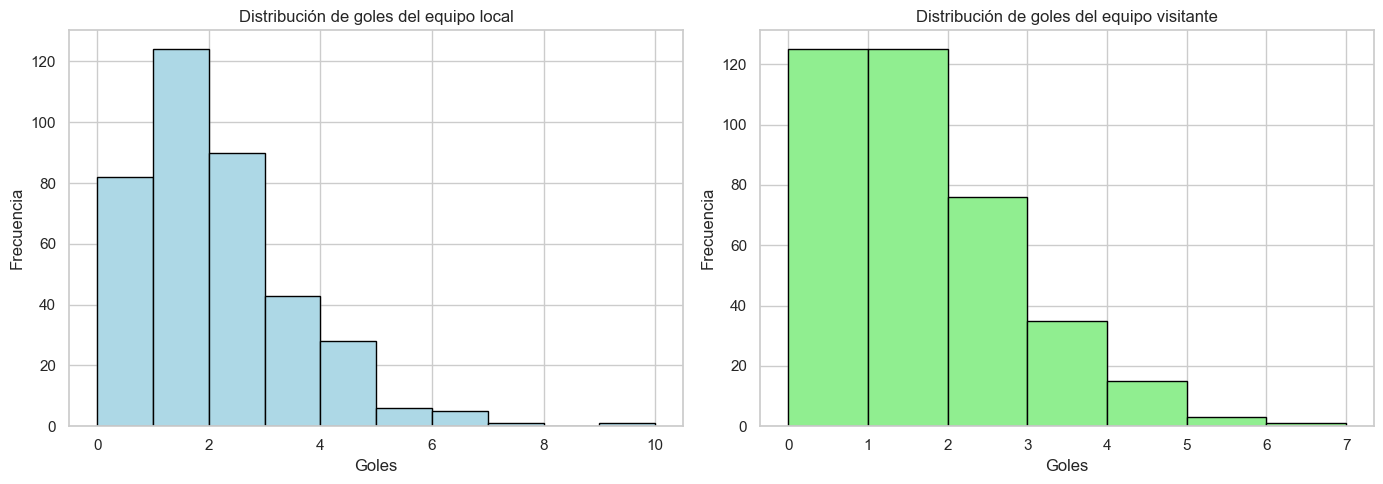

Media goles local:     1.634211
Media goles visitante: 1.218421


In [7]:
# Histogramas de goles (equivalente a hist() en R)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(datos['FTHG'], color='lightblue', edgecolor='black', bins=range(0, 11))
axes[0].set_title('Distribución de goles del equipo local')
axes[0].set_xlabel('Goles'); axes[0].set_ylabel('Frecuencia')

axes[1].hist(datos['FTAG'], color='lightgreen', edgecolor='black', bins=range(0, 8))
axes[1].set_title('Distribución de goles del equipo visitante')
axes[1].set_xlabel('Goles'); axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

# Media de goles (equivalente a mean() en R)
print(f"Media goles local:     {datos['FTHG'].mean():.6f}")
print(f"Media goles visitante: {datos['FTAG'].mean():.6f}")

A partir de los histogramas, se observa que la mayoría de los partidos presentan un número reducido de goles, concentrándose principalmente entre 0 y 2. La distribución presenta una clara asimetría hacia la derecha, lo que indica la existencia de algunos partidos con un número elevado de goles, aunque estos son poco frecuentes.

Además, se aprecia que los equipos locales tienden a marcar ligeramente más goles que los visitantes, lo que refuerza la hipótesis de la ventaja de jugar en casa. Este resultado también se confirma al observar que la media de goles del equipo local (1.63) es superior a la del equipo visitante (1.22).

En general, los partidos de la Premier League presentan un número moderado de goles, siendo poco frecuentes los encuentros con anotaciones muy elevadas. Asimismo, se confirma una ligera superioridad ofensiva de los equipos locales frente a los visitantes.

### 3.2. Distribución de resultados

En esta subsección se analiza en mayor profundidad la distribución de los resultados de los partidos, teniendo en cuenta variables adicionales que permiten contextualizar mejor dichos resultados. En particular, se estudia la relación entre el resultado del partido y el número total de goles anotados, con el objetivo de identificar posibles patrones en función de la intensidad ofensiva de los encuentros.

Frecuencias:
FTR
A    109
D     87
H    184
Name: count, dtype: int64

Proporciones:
FTR
A    0.286842
D    0.228947
H    0.484210
Name: proportion, dtype: float64


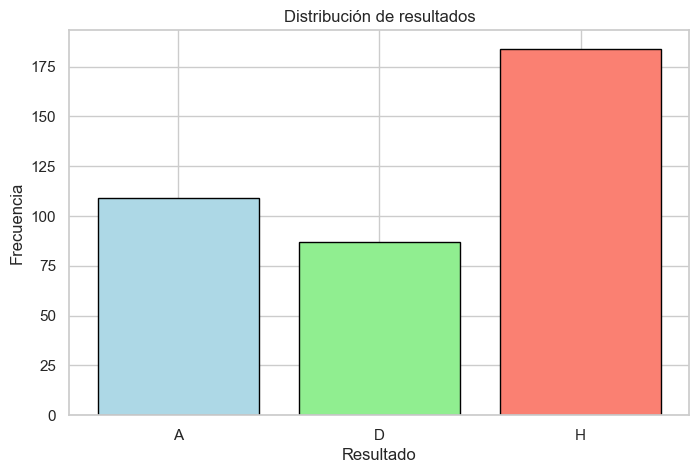

In [8]:
# Frecuencias y proporciones (equivalente a table() y prop.table() en R)
frecuencias  = datos['FTR'].value_counts().sort_index()
proporciones = datos['FTR'].value_counts(normalize=True).sort_index()

print("Frecuencias:")
print(frecuencias)
print("\nProporciones:")
print(proporciones.round(7))

# Gráfico de barras (equivalente a barplot() en R)
colores = {'A': 'lightblue', 'D': 'lightgreen', 'H': 'salmon'}
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(frecuencias.index, frecuencias.values,
       color=[colores[r] for r in frecuencias.index], edgecolor='black')
ax.set_title('Distribución de resultados')
ax.set_xlabel('Resultado'); ax.set_ylabel('Frecuencia')
plt.show()

Los resultados muestran que la victoria local es el resultado más frecuente con un 48.4% de los partidos, seguida de la victoria visitante con un 28.7% y el empate con un 22.9%, lo que sugiere la existencia de una clara ventaja de jugar en casa.

### 3.3. Comparación entre equipo local y visitante

En esta subsección se analiza la diferencia en el rendimiento ofensivo entre equipos locales y visitantes, con el objetivo de identificar posibles patrones asociados al factor campo. En lugar de repetir las variables ya analizadas anteriormente, se profundiza en indicadores clave como los tiros a puerta y la eficiencia, que permiten evaluar tanto la generación como la calidad de las ocasiones.

In [9]:
print(f"Media tiros a puerta local:     {datos['HST'].mean():.6f}")
print(f"Media tiros a puerta visitante: {datos['AST'].mean():.6f}")
print(f"Media eficiencia local:         {datos['EfficiencyHome'].mean():.7f}")
print(f"Media eficiencia visitante:     {datos['EfficiencyAway'].mean():.7f}")

Media tiros a puerta local:     4.907895
Media tiros a puerta visitante: 3.894737
Media eficiencia local:         0.3381971
Media eficiencia visitante:     0.3124512


Los resultados muestran que los equipos locales generan un mayor número de tiros a puerta (4.91) en comparación con los visitantes (3.89), lo que confirma una mayor capacidad de generar ocasiones claras de gol gracias al factor campo; sin embargo, al analizar la eficiencia ofensiva, se observa que las diferencias son mínimas (33.8% local frente a 31.2% visitante), lo que sugiere que ambos presentan una capacidad similar para transformar sus oportunidades en goles.

Se concluye así que la ventaja de jugar en casa está directamente relacionada con un mayor volumen de ataque y dominio del juego ofensivo más que con una precisión superior en la finalización de las jugadas.

### 3.4. Relación entre variables ofensivas y goles

En esta subsección se analiza la relación entre las variables ofensivas y el número de goles anotados, con el objetivo de comprender hasta qué punto la generación de ocasiones influye en el rendimiento ofensivo de los equipos. En particular, se estudia la relación entre el número de tiros, los tiros a puerta y los goles anotados, tanto para el equipo local como para el visitante.

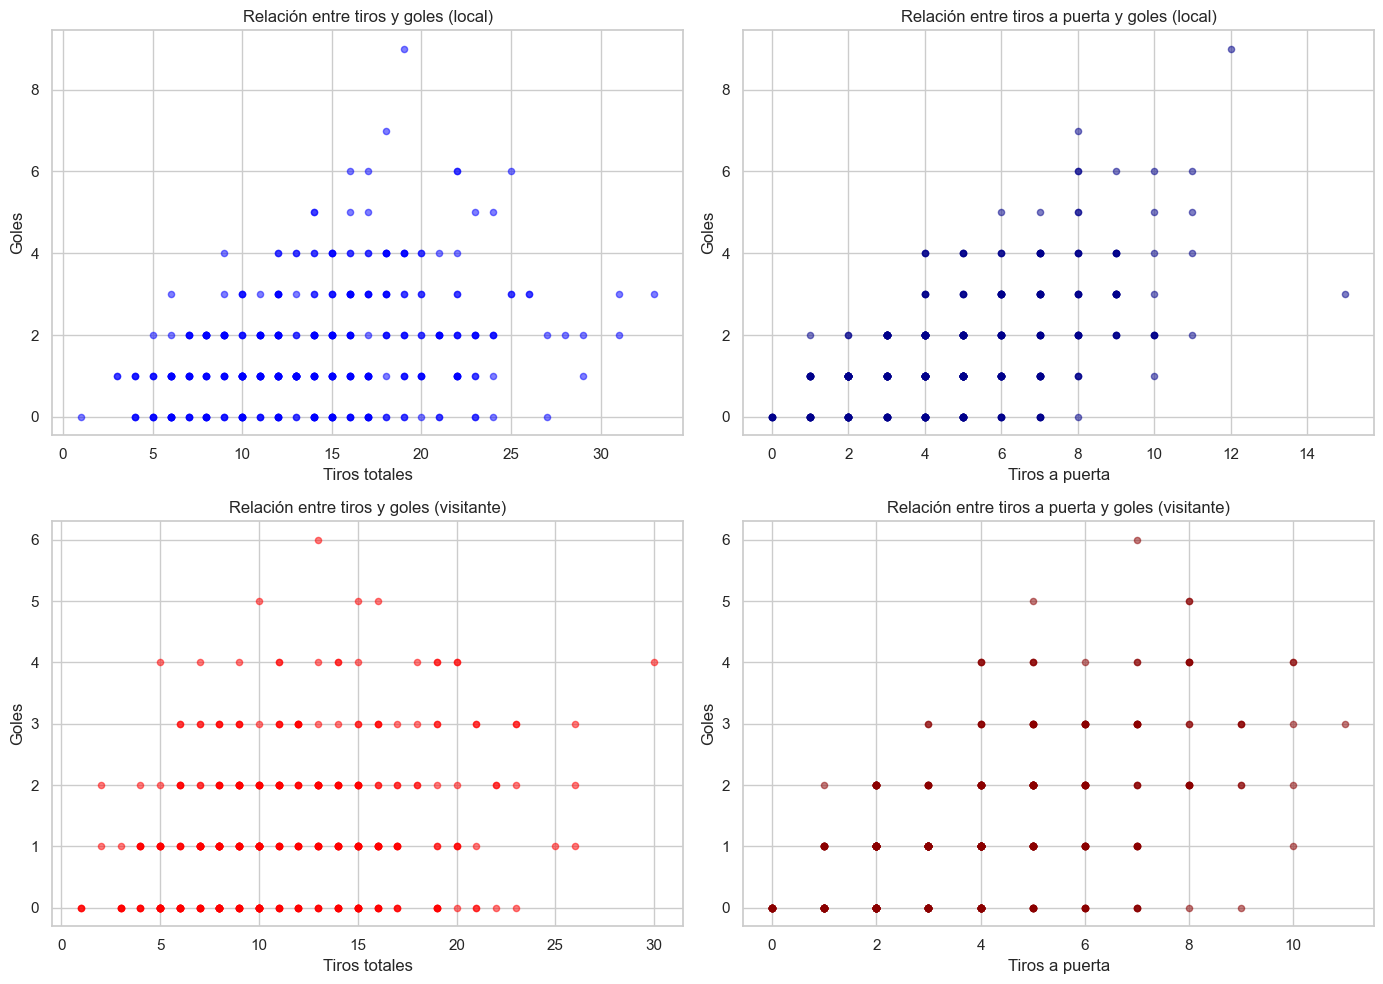

Correlación tiros totales - goles (local):      0.3346944
Correlación tiros a puerta - goles (local):     0.5914285
Correlación tiros totales - goles (visitante):  0.2523152
Correlación tiros a puerta - goles (visitante): 0.5404367


In [10]:
# Gráficos de dispersión (equivalente a plot() en R)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0,0].scatter(datos['HS'],  datos['FTHG'], color='blue',    alpha=0.5, s=20)
axes[0,0].set_title('Relación entre tiros y goles (local)')
axes[0,0].set_xlabel('Tiros totales'); axes[0,0].set_ylabel('Goles')

axes[0,1].scatter(datos['HST'], datos['FTHG'], color='darkblue', alpha=0.5, s=20)
axes[0,1].set_title('Relación entre tiros a puerta y goles (local)')
axes[0,1].set_xlabel('Tiros a puerta'); axes[0,1].set_ylabel('Goles')

axes[1,0].scatter(datos['AS'],  datos['FTAG'], color='red',     alpha=0.5, s=20)
axes[1,0].set_title('Relación entre tiros y goles (visitante)')
axes[1,0].set_xlabel('Tiros totales'); axes[1,0].set_ylabel('Goles')

axes[1,1].scatter(datos['AST'], datos['FTAG'], color='darkred', alpha=0.5, s=20)
axes[1,1].set_title('Relación entre tiros a puerta y goles (visitante)')
axes[1,1].set_xlabel('Tiros a puerta'); axes[1,1].set_ylabel('Goles')

plt.tight_layout()
plt.show()

# Correlaciones (equivalente a cor() en R)
print(f"Correlación tiros totales - goles (local):      {datos['HS'].corr(datos['FTHG']):.7f}")
print(f"Correlación tiros a puerta - goles (local):     {datos['HST'].corr(datos['FTHG']):.7f}")
print(f"Correlación tiros totales - goles (visitante):  {datos['AS'].corr(datos['FTAG']):.7f}")
print(f"Correlación tiros a puerta - goles (visitante): {datos['AST'].corr(datos['FTAG']):.7f}")

Los gráficos de dispersión corroboran visualmente que la relación entre los tiros a puerta y los goles es mucho más lineal y agrupada que la de los tiros totales, la cual presenta una gran dispersión de puntos que indica ataques ineficientes. Esta diferencia se refleja en las correlaciones calculadas, donde el equipo local pasa de un 0.33 en tiros totales a un 0.59 en tiros a puerta, mientras que el visitante sube de 0.25 a 0.54.

Al observar los ejes de los gráficos, se confirma que los equipos locales no solo muestran una asociación más estrecha entre sus intentos y el marcador, sino que mantienen un volumen ofensivo superior, con una media de 1.63 goles frente al 1.22 de los visitantes.

En definitiva, los plots demuestran que la precisión y la calidad de las ocasiones (tiros a puerta) son los factores realmente determinantes para explicar el éxito goleador en la Premier League, por encima del simple volumen de disparos realizados.

### 3.5. Correlaciones entre variables numéricas

En esta subsección se analizan las correlaciones entre las variables numéricas del dataset, con el objetivo de identificar relaciones lineales entre diferentes aspectos del juego. El estudio de las correlaciones permite comprender qué variables están más relacionadas entre sí, facilitando la interpretación del comportamiento del dataset y ayudando en la selección de variables para modelos posteriores.

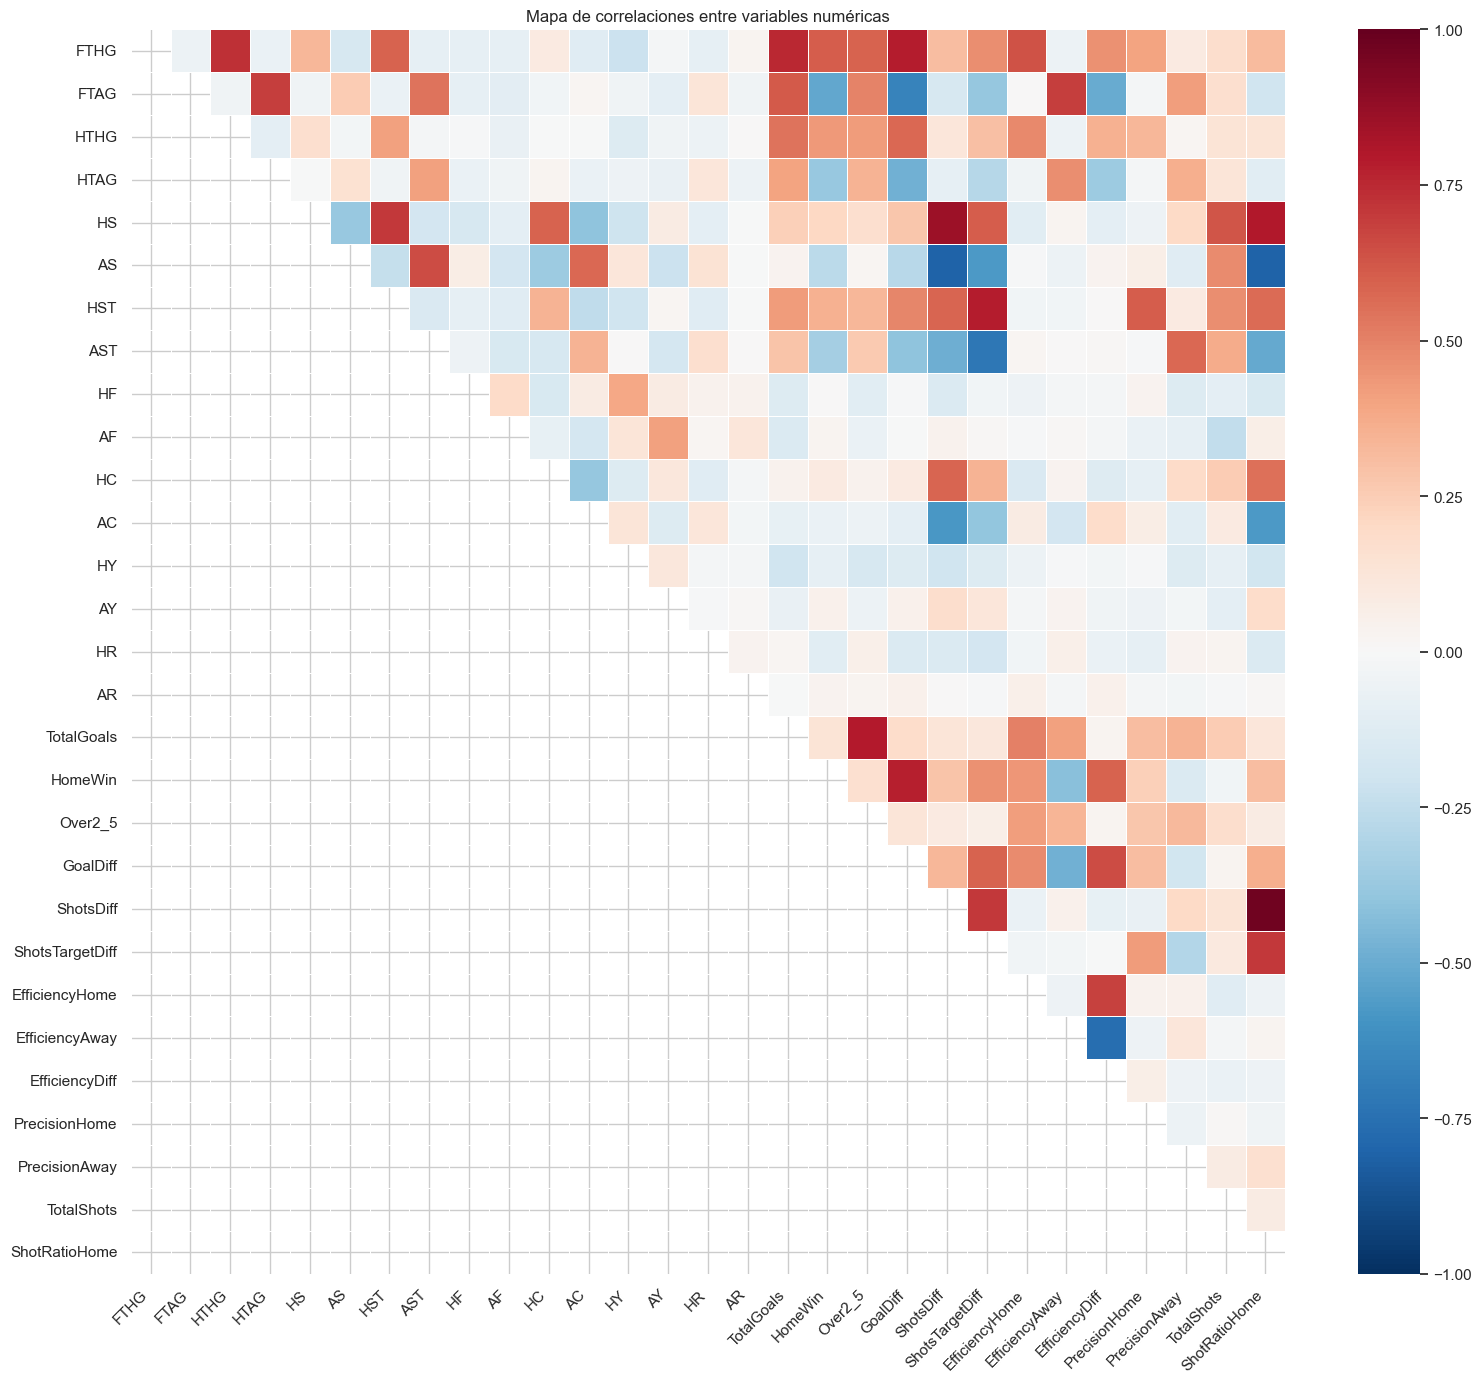

In [11]:
# Selección de variables numéricas (equivalente a sapply(datos, is.numeric) en R)
vars_numericas = datos.select_dtypes(include=[np.number])
correlaciones  = vars_numericas.corr()

# Mapa de correlaciones (equivalente a corrplot() en R)
fig, ax = plt.subplots(figsize=(16, 14))
mask = np.triu(np.ones_like(correlaciones, dtype=bool), k=1)  # Triángulo superior
sns.heatmap(correlaciones, mask=~mask, annot=False, cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax, linewidths=0.5)
ax.set_title('Mapa de correlaciones entre variables numéricas')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

El mapa de correlaciones permite visualizar de forma clara las relaciones entre las variables numéricas del dataset. En primer lugar, se observan fuertes correlaciones positivas entre variables directamente relacionadas, como los goles del equipo local y visitante con el número total de goles, lo cual es esperable debido a su propia definición.

Asimismo, se aprecia una relación positiva entre el número de tiros y los tiros a puerta, lo que indica que los equipos que generan más ocasiones tienden también a producir un mayor número de disparos efectivos. Por otro lado, las variables relacionadas con la eficiencia y la precisión presentan correlaciones más moderadas, lo que sugiere que la calidad de las ocasiones no depende exclusivamente del volumen de tiros realizados.

Además, se observan algunas correlaciones negativas entre variables de equipos opuestos, reflejando la naturaleza competitiva del juego, donde el dominio de un equipo suele implicar menor rendimiento del rival. En conjunto, el análisis confirma que las variables ofensivas están interrelacionadas, siendo especialmente relevantes aquellas que miden la calidad de las ocasiones generadas.

---
## 4. ¿Existe realmente la ventaja de jugar en casa?

En esta sección se aplican técnicas de inferencia estadística con el objetivo de validar de forma rigurosa si la ventaja de jugar en casa es estadísticamente significativa o si podría deberse al azar. Para ello, se emplean intervalos de confianza y contrastes de hipótesis sobre variables clave del estudio.

### 4.1. Intervalo de confianza para la media de goles locales

En esta subsección se estima la media de goles anotados por los equipos locales mediante la construcción de un intervalo de confianza. El objetivo es obtener un rango en el que se encuentre la media poblacional con un determinado nivel de confianza, en este caso del 95%.

In [12]:
# Intervalo de confianza al 95% (equivalente a t.test() en R)
n      = len(datos['FTHG'])
media  = datos['FTHG'].mean()
std    = datos['FTHG'].std(ddof=1)
error  = std / np.sqrt(n)
t_crit = stats.t.ppf(0.975, df=n-1)
ic_low, ic_high = media - t_crit * error, media + t_crit * error

ic = ttest_1samp(datos['FTHG'], popmean=0)

print(f"Media muestral:      {media:.6f}")
print(f"Desviación típica:   {std:.6f}")
print(f"Tamaño muestral (n): {n}")
print(f"IC 95%: [{ic_low:.6f}, {ic_high:.6f}]")
print(f"t = {ic.statistic:.4f},  p-valor = {ic.pvalue:.2e}")

Media muestral:      1.634211
Desviación típica:   1.419944
Tamaño muestral (n): 380
IC 95%: [1.490986, 1.777435]
t = 22.4351,  p-valor = 1.54e-71


El intervalo de confianza obtenido permite estimar la media real de goles anotados por los equipos locales en la competición. Con un nivel de confianza del 95%, se puede afirmar que la media poblacional se encuentra dentro del intervalo calculado [1.490986, 1.777435].

Dado que la media muestral es aproximadamente 1.63 goles por partido, los resultados reflejan una capacidad ofensiva destacada de los equipos locales. Además, el intervalo obtenido presenta una amplitud moderada, lo que indica que la estimación es relativamente precisa a pesar de la variabilidad existente.

### 4.2. Contraste de medias: goles local vs visitante

En esta subsección se analiza si existen diferencias significativas entre el número de goles anotados por los equipos locales y visitantes. Se plantea el siguiente contraste de hipótesis:

- **H₀**: La media de goles de los equipos locales es igual a la de los visitantes.
- **H₁**: La media de goles de los equipos locales es mayor que la de los visitantes.

In [13]:
# Test t de Welch unilateral (equivalente a t.test(..., alternative='greater') en R)
t_stat, p_valor = ttest_ind(datos['FTHG'], datos['FTAG'],
                             equal_var=False, alternative='greater')

print(f"Media goles local:     {datos['FTHG'].mean():.6f}")
print(f"Media goles visitante: {datos['FTAG'].mean():.6f}")
print(f"t = {t_stat:.4f}")
print(f"p-valor = {p_valor:.2e}")

Media goles local:     1.634211
Media goles visitante: 1.218421
t = 4.3848
p-valor = 6.65e-06


Dado que el p-valor (6.654e-06) es significativamente inferior al nivel de error permitido (0.05), existe evidencia estadística suficiente para rechazar la hipótesis nula. Esto confirma que la diferencia entre la media de goles locales (1.63) y visitantes (1.22) no se debe al azar, validando de forma científica la existencia de una ventaja de jugar en casa en esta competición. En promedio, los equipos locales anotan 0.42 goles más por partido que los visitantes (diferencia de 0.4158).

### 4.3. Contraste de medias: tiros a puerta local vs visitante

En esta subsección se analiza si existen diferencias significativas entre el número de tiros a puerta realizados por los equipos locales y visitantes.

- **H₀**: La media de tiros a puerta es igual para ambos.
- **H₁**: La media de tiros a puerta del equipo local es mayor que la del visitante.

In [14]:
t_stat_tp, p_valor_tp = ttest_ind(datos['HST'], datos['AST'],
                                   equal_var=False, alternative='greater')

print(f"Media tiros a puerta local:     {datos['HST'].mean():.6f}")
print(f"Media tiros a puerta visitante: {datos['AST'].mean():.6f}")
print(f"t = {t_stat_tp:.4f}")
print(f"p-valor = {p_valor_tp:.2e}")

Media tiros a puerta local:     4.907895
Media tiros a puerta visitante: 3.894737
t = 5.9009
p-valor = 2.74e-09


Al realizar el contraste de medias para los tiros a puerta, se ha obtenido un p-valor de 2.737e-09, el cual es muy inferior al nivel de significancia de 0.05, lo que obliga a rechazar la hipótesis nula y confirmar que existe una diferencia estadísticamente significativa entre ambos grupos.

Los resultados muestran que los equipos locales generan un mayor volumen ofensivo con una media de 4.91 tiros a puerta por partido frente a los 3.89 de los visitantes, con un intervalo de confianza que indica que la ventaja local es de al menos 0.73 disparos. Esta evidencia estadística confirma un mayor dominio de los equipos de casa en la generación de ocasiones claras, reforzando la conclusión de que el factor campo influye de manera determinante en el comportamiento ofensivo durante la competición.

### 4.4. Test Chi-cuadrado: tarjetas rojas vs resultado

En esta subsección se analiza si existe relación entre la presencia de tarjetas rojas y el resultado final del partido. A diferencia de los apartados anteriores, en este caso se trabaja con variables categóricas, por lo que se emplea el test Chi-cuadrado.

- Si el p-valor es inferior a 0.05, se rechaza la hipótesis nula, concluyendo que existe relación entre ambas variables.
- Si el p-valor es superior a 0.05, no se puede afirmar que exista una relación significativa entre las variables analizadas.

In [15]:
# Crear variable: presencia de expulsión (equivalente a ifelse(HR+AR>0,1,0) en R)
datos['RedCard'] = ((datos['HR'] + datos['AR']) > 0).astype(int)

# Tabla de contingencia (equivalente a table() en R)
tabla_red = pd.crosstab(datos['FTR'], datos['RedCard'])
print("Tabla de contingencia:")
print(tabla_red)

# Proporciones (equivalente a prop.table(margin=2) en R)
print("\nProporciones por columna:")
print(tabla_red.div(tabla_red.sum(axis=0), axis=1).round(7))

# Test Chi-cuadrado (equivalente a chisq.test() en R)
chi2, p_chi, dof, _ = chi2_contingency(tabla_red)
print(f"\nChi² = {chi2:.4f},  df = {dof},  p-valor = {p_chi:.4f}")

Tabla de contingencia:
RedCard    0   1
FTR             
A        100   9
D         80   7
H        174  10

Proporciones por columna:
RedCard         0         1
FTR                        
A        0.282486  0.346154
D        0.225989  0.269231
H        0.491525  0.384615

Chi² = 1.1118,  df = 2,  p-valor = 0.5735


Dado que el p-valor obtenido es de 0.5735, el cual es superior al nivel de significancia de 0.05, no se puede rechazar la hipótesis nula, concluyendo que no se dispone de evidencia suficiente para afirmar que exista una relación estadísticamente significativa entre la presencia de expulsiones y el resultado final del partido en esta muestra.

---
## 5. ¿Cuánto de bueno es cada equipo realmente?

En esta sección se aplica el modelo Dixon-Coles, un modelo estadístico de referencia en la analítica de fútbol, con el objetivo de estimar la fuerza ofensiva y la debilidad defensiva de cada equipo de forma independiente al resultado final de la temporada.

A diferencia de la clasificación oficial, que mezcla calidad y suerte, este modelo permite separar ambos factores, asignando a cada equipo dos parámetros latentes: su capacidad de ataque y su solidez defensiva. Además, se incorpora un parámetro de ventaja local que captura el efecto del factor campo de forma explícita.

La estimación de los parámetros se realiza por máxima verosimilitud, asumiendo que los goles de cada equipo siguen distribuciones de Poisson independientes cuyas medias dependen de la fuerza de ataque del equipo que marca y de la debilidad defensiva del equipo que encaja.

### 5.1. Modelo Dixon-Coles: estimación por máxima verosimilitud

En esta subsección se construye y estima el modelo Dixon-Coles. La idea central es modelizar los goles de cada equipo como variables aleatorias de Poisson cuya media depende de tres factores: la fuerza de ataque del equipo que marca, la debilidad defensiva del equipo que encaja, y la ventaja de jugar en casa. Los parámetros del modelo se estiman por máxima verosimilitud mediante optimización numérica.

In [16]:
# Equipos de la temporada (orden alfabético, igual que levels() en R)
equipos    = sorted(datos['HomeTeam'].unique())
n_equipos  = len(equipos)
idx_equipo = {e: i for i, e in enumerate(equipos)}

# Índices de local y visitante de cada partido (para vectorizar la verosimilitud)
home_idx_dc = datos['HomeTeam'].map(idx_equipo).values
away_idx_dc = datos['AwayTeam'].map(idx_equipo).values
fthg_arr, ftag_arr = datos['FTHG'].values, datos['FTAG'].values

# Log-verosimilitud negativa del modelo Dixon-Coles (equivalente a la de R)
def log_verosimilitud(params):
    ataque  = params[:n_equipos]
    defensa = params[n_equipos:2*n_equipos]
    ventaja = params[2*n_equipos]
    lambda_home = np.exp(ventaja + ataque[home_idx_dc] - defensa[away_idx_dc])
    lambda_away = np.exp(ataque[away_idx_dc] - defensa[home_idx_dc])
    return -(poisson.logpmf(fthg_arr, lambda_home).sum() +
             poisson.logpmf(ftag_arr, lambda_away).sum())

# Estimación por máxima verosimilitud (BFGS, igual que optim() en R; determinista)
params_iniciales = np.zeros(2*n_equipos + 1)
params_iniciales[2*n_equipos] = 0.1
resultado = minimize(log_verosimilitud, params_iniciales,
                     method='BFGS', options={'maxiter': 10000})

ataque_est  = dict(zip(equipos, resultado.x[:n_equipos]))
defensa_est = dict(zip(equipos, resultado.x[n_equipos:2*n_equipos]))
ventaja_est = resultado.x[2*n_equipos]
print(f"Ventaja local estimada: {ventaja_est:.4f}")

Ventaja local estimada: 0.2936


La ventaja local estimada es de 0.2937, lo que implica que jugar en casa multiplica por exp(0.2937) = 1.34 los goles esperados de media. Es decir, un equipo marca aproximadamente un 34% más de goles jugando en casa que fuera, independientemente de su calidad. Este resultado es consistente con los contrastes de hipótesis de la sección 4, donde ya se confirmó estadísticamente la existencia de ventaja local.

### 5.2. Ranking de fuerza de ataque y debilidad defensiva

En esta subsección se construye una tabla con los parámetros estimados para cada equipo. Un valor de ataque alto indica mayor capacidad ofensiva. Un valor de defensa bajo indica mayor solidez defensiva, ya que el parámetro de defensa representa la debilidad: cuanto menor, más difícil es marcarle al equipo.

Ranking por fuerza de ataque:
        Equipo  Ataque  Defensa
      Man City  0.6439   0.3713
       Arsenal  0.5877   0.1116
     Liverpool  0.4312   0.0353
      Brighton  0.3962  -0.0823
     Tottenham  0.3779  -0.2538
     Newcastle  0.3193   0.3968
     Brentford  0.1724   0.0736
    Man United  0.1695   0.1412
        Fulham  0.1260  -0.0656
     Leicester  0.0650  -0.3116
   Aston Villa  0.0435   0.0803
         Leeds  0.0140  -0.4463
      West Ham -0.1424  -0.0901
Crystal Palace -0.1970   0.0276
    Nottingham -0.2301  -0.2989
       Chelsea -0.2503   0.0712
   Bournemouth -0.2539  -0.3412
   Southampton -0.2794  -0.3680
       Everton -0.3522  -0.1182
        Wolves -0.4438  -0.1327

Ranking por solidez defensiva (menor valor = mejor defensa):
        Equipo  Ataque  Defensa
         Leeds  0.0140  -0.4463
   Southampton -0.2794  -0.3680
   Bournemouth -0.2539  -0.3412
     Leicester  0.0650  -0.3116
    Nottingham -0.2301  -0.2989
     Tottenham  0.3779  -0.2538
        Wolv

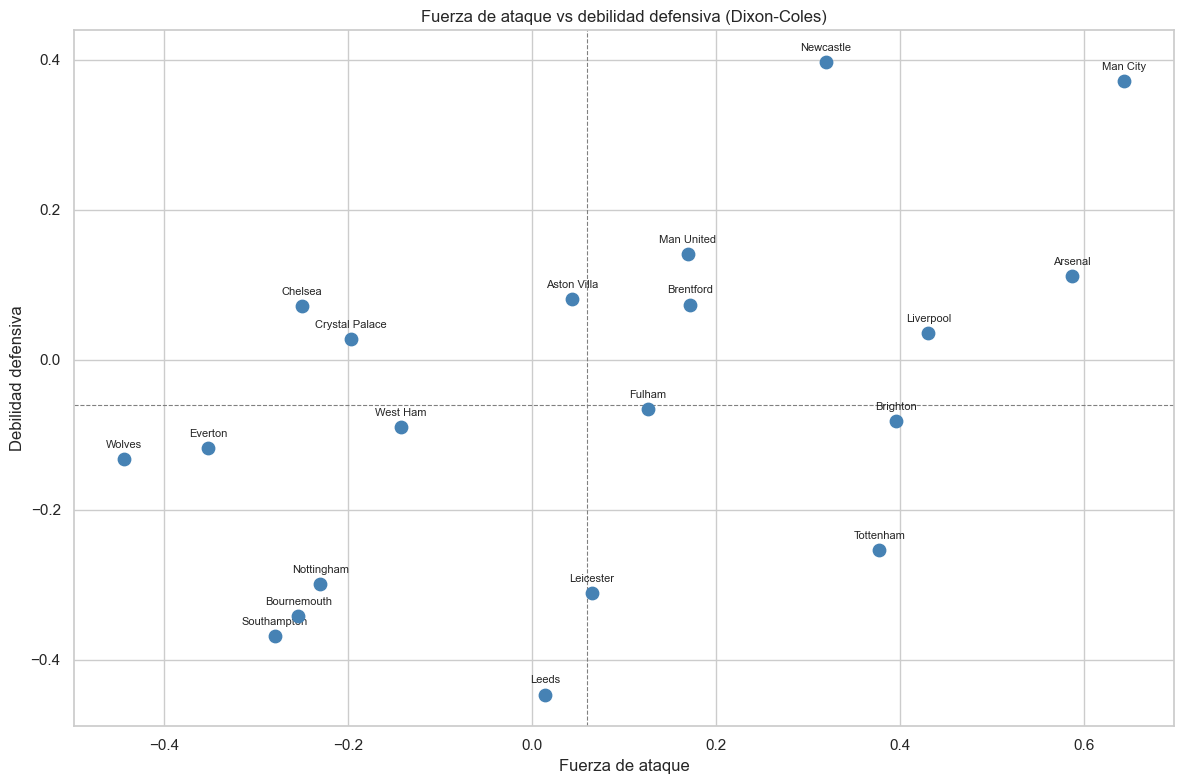

In [17]:
tabla_dc = pd.DataFrame({
    'Equipo':  equipos,
    'Ataque':  [round(ataque_est[e], 4) for e in equipos],
    'Defensa': [round(defensa_est[e], 4) for e in equipos]
})

print("Ranking por fuerza de ataque:")
print(tabla_dc.sort_values('Ataque', ascending=False).to_string(index=False))

print("\nRanking por solidez defensiva (menor valor = mejor defensa):")
print(tabla_dc.sort_values('Defensa').to_string(index=False))

# Gráfico ataque vs defensa (equivalente a plot() + text() + abline() en R)
fig, ax = plt.subplots(figsize=(12, 8))
ax.scatter(tabla_dc['Ataque'], tabla_dc['Defensa'], color='steelblue', s=80, zorder=5)
for _, fila in tabla_dc.iterrows():
    ax.annotate(fila['Equipo'], (fila['Ataque'], fila['Defensa']),
                textcoords='offset points', xytext=(0, 8), ha='center', fontsize=8)
ax.axhline(tabla_dc['Defensa'].mean(), linestyle='--', color='gray', linewidth=0.8)
ax.axvline(tabla_dc['Ataque'].mean(),  linestyle='--', color='gray', linewidth=0.8)
ax.set_title('Fuerza de ataque vs debilidad defensiva (Dixon-Coles)')
ax.set_xlabel('Fuerza de ataque'); ax.set_ylabel('Debilidad defensiva')
plt.tight_layout()
plt.show()

El gráfico revela cuatro perfiles claramente diferenciados. Man City y Arsenal destacan como los equipos más completos, combinando alto ataque con baja debilidad defensiva, lo que los sitúa como los candidatos reales al título. Brighton y Liverpool también presentan una buena combinación de ambos parámetros.

Newcastle llama la atención por su alto ataque pero también alta debilidad defensiva, perfil de equipo ofensivo pero frágil atrás. En el extremo opuesto, Southampton, Bournemouth y Leeds combinan bajo ataque con alta debilidad defensiva, lo que explica sus problemas para mantenerse en la categoría. Wolves y Everton presentan bajo ataque pero buena solidez defensiva, perfil típico de equipos que compiten bien en la tabla pero sin capacidad real de amenazar los puestos europeos.

### 5.3. Comparación con la clasificación real

En esta subsección se comparan los parámetros estimados por el modelo Dixon-Coles con la clasificación real de la temporada 2022-2023. El objetivo es evaluar en qué medida la calidad estimada por el modelo coincide con el rendimiento real, y detectar equipos que rindieron por encima o por debajo de su nivel esperado.

Comparación clasificación real vs Dixon-Coles:
        Equipo  Puntos  Posicion_Real  Posicion_DC  Diferencia
      Man City      89              1            1           0
       Arsenal      84              2            2           0
    Man United      75              3            8          -5
     Newcastle      71              4            6          -2
     Liverpool      67              5            3           2
      Brighton      62              6            4           2
   Aston Villa      61              7           11          -4
     Tottenham      60              8            5           3
     Brentford      59              9            7           2
        Fulham      52             10            9           1
Crystal Palace      45             11           14          -3
       Chelsea      44             12           16          -4
        Wolves      41             13           20          -7
      West Ham      40             14           13           1
   Bourn

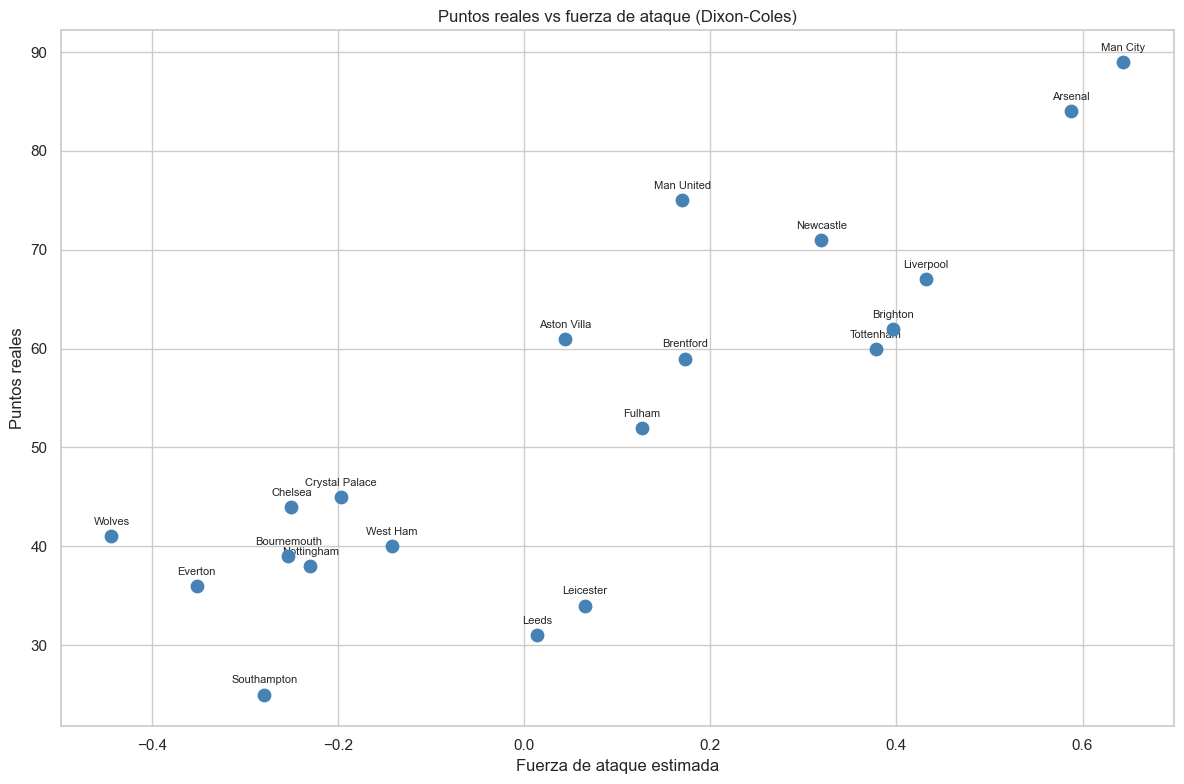

In [18]:
# Cálculo de puntos reales (equivalente al bucle for en R)
puntos_real = {e: 0 for e in equipos}
for _, fila in datos.iterrows():
    home, away, res = fila['HomeTeam'], fila['AwayTeam'], fila['FTR']
    if res == 'H':   puntos_real[home] += 3
    elif res == 'A': puntos_real[away] += 3
    else:            puntos_real[home] += 1; puntos_real[away] += 1

df_puntos = pd.DataFrame({'Equipo': list(puntos_real.keys()),
                           'Puntos': list(puntos_real.values())})
df_puntos = df_puntos.sort_values('Puntos', ascending=False).reset_index(drop=True)
df_puntos['Posicion_Real'] = range(1, len(df_puntos) + 1)

comparacion = df_puntos.merge(tabla_dc, on='Equipo')
comparacion = comparacion.sort_values('Ataque', ascending=False).reset_index(drop=True)
comparacion['Posicion_DC'] = range(1, len(comparacion) + 1)
comparacion['Diferencia']  = comparacion['Posicion_Real'] - comparacion['Posicion_DC']
comparacion = comparacion.sort_values('Posicion_Real')

print("Comparación clasificación real vs Dixon-Coles:")
print(comparacion[['Equipo','Puntos','Posicion_Real','Posicion_DC','Diferencia']].to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 8))
ax.scatter(comparacion['Ataque'], comparacion['Puntos'], color='steelblue', s=80, zorder=5)
for _, fila in comparacion.iterrows():
    ax.annotate(fila['Equipo'], (fila['Ataque'], fila['Puntos']),
                textcoords='offset points', xytext=(0, 8), ha='center', fontsize=8)
ax.set_title('Puntos reales vs fuerza de ataque (Dixon-Coles)')
ax.set_xlabel('Fuerza de ataque estimada'); ax.set_ylabel('Puntos reales')
plt.tight_layout()
plt.show()

Los resultados muestran que Man City y Arsenal coinciden perfectamente entre su posición real y la estimada por Dixon-Coles, confirmando que su rendimiento estuvo completamente alineado con su calidad real.

Los casos más llamativos son Leicester y Leeds, que terminaron mucho más abajo en la clasificación real de lo que su calidad estimada sugería, lo que apunta a mala suerte o ineficiencia en momentos clave. En sentido contrario, Wolves y Aston Villa rindieron por encima de su calidad estimada. Man United también aparece sobrerendiendo: el modelo estima que su nivel ofensivo no justifica un tercer puesto.

Estas diferencias motivan directamente la sección siguiente, donde la simulación Monte Carlo cuantificará el papel exacto de la suerte en la clasificación final.

---
## 6. ¿Quién habría ganado la liga en otras circunstancias?

En esta sección se simula la temporada 2022-2023 de la Premier League 10.000 veces utilizando los parámetros estimados por el modelo Dixon-Coles. El objetivo es cuantificar el papel de la suerte en la clasificación final, obteniendo distribuciones de probabilidad para cada equipo de ser campeón, terminar en el top 4 o descender.

### 6.1. Simulación Monte Carlo (10.000 iteraciones)

En esta subsección se implementa la simulación Monte Carlo. Para cada iteración se simulan los 380 partidos de la temporada generando marcadores aleatorios mediante distribuciones de Poisson con los parámetros estimados por Dixon-Coles. A partir de cada simulación se obtiene una clasificación final completa.

In [19]:
import os
# PUENTE R -> Python: si existe montecarlo_probs.csv (tabla 20x4 de R) se usa directamente;
# la simulación con Poisson es estocástica y no reproduciría los valores exactos de R.
if os.path.exists('montecarlo_probs.csv'):
    tabla_mc = pd.read_csv('montecarlo_probs.csv')
    tabla_mc = tabla_mc.sort_values('Campeon', ascending=False).reset_index(drop=True)
    bridge_mc = True
    print("Probabilidades Monte Carlo cargadas desde R (idénticas a R)")
else:
    bridge_mc = False
    print("AVISO: montecarlo_probs.csv no encontrado. Se simula en Python (diferirá de R).")
    np.random.seed(42)
    n_sim = 10000
    lh = np.exp(ventaja_est + np.array([ataque_est[h] for h in datos['HomeTeam']])
                            - np.array([defensa_est[a] for a in datos['AwayTeam']]))
    la = np.exp(np.array([ataque_est[a] for a in datos['AwayTeam']])
                - np.array([defensa_est[h] for h in datos['HomeTeam']]))
    home_idx = np.array([idx_equipo[h] for h in datos['HomeTeam']])
    away_idx = np.array([idx_equipo[a] for a in datos['AwayTeam']])
    n_partidos = len(datos)
    goles_h = np.random.poisson(lh, size=(n_sim, n_partidos))
    goles_a = np.random.poisson(la, size=(n_sim, n_partidos))
    puntos = np.zeros((n_sim, n_equipos))
    lw, aw, dr = goles_h > goles_a, goles_a > goles_h, goles_h == goles_a
    for i in range(n_partidos):
        np.add.at(puntos, (np.arange(n_sim)[lw[:, i]], home_idx[i]), 3)
        np.add.at(puntos, (np.arange(n_sim)[aw[:, i]], away_idx[i]), 3)
        np.add.at(puntos, (np.arange(n_sim)[dr[:, i]], home_idx[i]), 1)
        np.add.at(puntos, (np.arange(n_sim)[dr[:, i]], away_idx[i]), 1)
    ruido = np.random.uniform(0, 1e-6, puntos.shape)
    orden = np.argsort(-(puntos + ruido), axis=1)
    posiciones = np.empty_like(orden)
    np.put_along_axis(posiciones, orden, np.tile(np.arange(1, n_equipos+1), (n_sim, 1)), axis=1)

Probabilidades Monte Carlo cargadas desde R (idénticas a R)


La simulación genera 10.000 temporadas alternativas partiendo de la misma calidad estimada para cada equipo pero con resultados aleatorios en cada partido. Esto permite obtener distribuciones de probabilidad completas para cada posición de la clasificación final.

### 6.2. Probabilidades de campeón, top 4 y descenso

En esta subsección se calculan las probabilidades de cada equipo de ser campeón, terminar en el top 4 (clasificación europea) y descender (posiciones 18, 19 y 20) a partir de las 10.000 simulaciones.

Probabilidades Monte Carlo (%):
        Equipo  Campeon  Top4  Descenso
      Man City     71.6  99.3       0.0
       Arsenal     16.0  90.1       0.0
     Newcastle      8.8  80.9       0.0
     Liverpool      2.4  53.7       0.0
      Brighton      0.6  26.7       0.0
    Man United      0.3  19.8       0.0
     Brentford      0.2  13.1       0.0
     Tottenham      0.1   7.2       0.1
   Aston Villa      0.0   5.1       0.3
   Bournemouth      0.0   0.0      55.4
       Chelsea      0.0   0.2       5.2
Crystal Palace      0.0   0.2       5.0
       Everton      0.0   0.0      30.5
        Fulham      0.0   3.5       0.5
         Leeds      0.0   0.0      32.2
     Leicester      0.0   0.1       9.2
    Nottingham      0.0   0.0      44.2
   Southampton      0.0   0.0      63.6
      West Ham      0.0   0.1       7.9
        Wolves      0.0   0.0      45.6


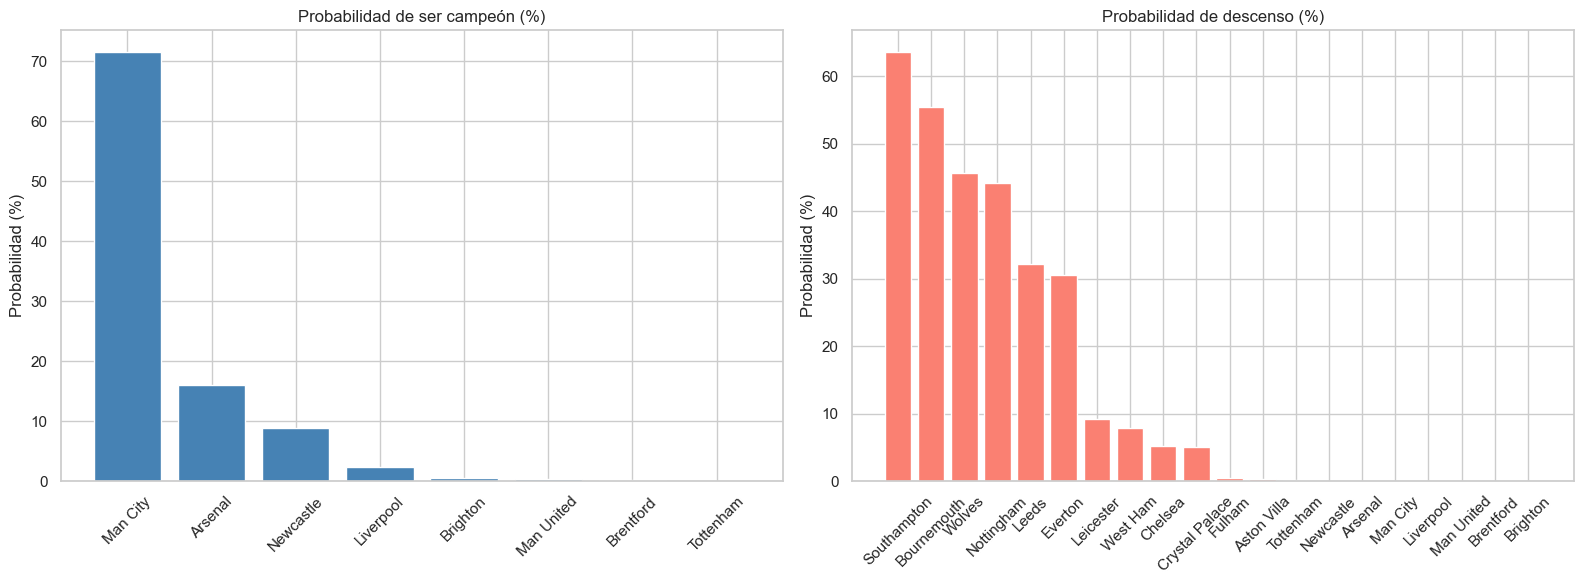

In [20]:
# Si no se cargó del puente, se calculan las probabilidades a partir de las posiciones simuladas
if not bridge_mc:
    prob_campeon  = np.mean(posiciones == 1,  axis=0) * 100
    prob_top4     = np.mean(posiciones <= 4,  axis=0) * 100
    prob_descenso = np.mean(posiciones >= 18, axis=0) * 100
    tabla_mc = pd.DataFrame({'Equipo': equipos,
                              'Campeon':  prob_campeon.round(1),
                              'Top4':     prob_top4.round(1),
                              'Descenso': prob_descenso.round(1)})
    tabla_mc = tabla_mc.sort_values('Campeon', ascending=False).reset_index(drop=True)

print("Probabilidades Monte Carlo (%):")
print(tabla_mc.to_string(index=False))

# Gráficos (equivalente a barplot() en R)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
tabla_camp = tabla_mc[tabla_mc['Campeon'] > 0]
axes[0].bar(tabla_camp['Equipo'], tabla_camp['Campeon'], color='steelblue')
axes[0].set_title('Probabilidad de ser campeón (%)'); axes[0].set_ylabel('Probabilidad (%)')
axes[0].tick_params(axis='x', rotation=45)
tabla_desc = tabla_mc.sort_values('Descenso', ascending=False)
axes[1].bar(tabla_desc['Equipo'], tabla_desc['Descenso'], color='salmon')
axes[1].set_title('Probabilidad de descenso (%)'); axes[1].set_ylabel('Probabilidad (%)')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()

Los resultados de la simulación revelan una jerarquía muy clara en la Premier League 2022-2023. Man City fue campeón en el 71.6% de las simulaciones, confirmando que su título no fue casualidad sino una superioridad real y contundente sobre el resto. Arsenal aparece como el único rival real con un 16.0% de probabilidad de título y un 90.1% de terminar en el top 4, lo que confirma que la lucha por el campeonato fue genuinamente disputada entre estos dos equipos. Newcastle sorprende con un 8.8% de probabilidad de título, siendo el tercer equipo con más opciones reales según el modelo.

En el extremo inferior, Southampton presenta la mayor probabilidad de descenso con un 63.6%, seguida de Bournemouth con un 55.4% y Wolves con un 45.6%.

### 6.3. Separando calidad de fortuna

En esta subsección se compara la clasificación real con las probabilidades estimadas por Monte Carlo para identificar equipos que tuvieron suerte positiva o negativa a lo largo de la temporada.

In [21]:
# Unión con clasificación real (equivalente a merge() en R)
tabla_final = tabla_mc.merge(df_puntos[['Equipo','Puntos','Posicion_Real']], on='Equipo')
tabla_final = tabla_final.sort_values('Posicion_Real')

print("Clasificación real vs probabilidades Monte Carlo:")
print(tabla_final[['Equipo','Puntos','Posicion_Real','Campeon','Top4','Descenso']].to_string(index=False))

Clasificación real vs probabilidades Monte Carlo:
        Equipo  Puntos  Posicion_Real  Campeon  Top4  Descenso
      Man City      89              1     71.6  99.3       0.0
       Arsenal      84              2     16.0  90.1       0.0
    Man United      75              3      0.3  19.8       0.0
     Newcastle      71              4      8.8  80.9       0.0
     Liverpool      67              5      2.4  53.7       0.0
      Brighton      62              6      0.6  26.7       0.0
   Aston Villa      61              7      0.0   5.1       0.3
     Tottenham      60              8      0.1   7.2       0.1
     Brentford      59              9      0.2  13.1       0.0
        Fulham      52             10      0.0   3.5       0.5
Crystal Palace      45             11      0.0   0.2       5.0
       Chelsea      44             12      0.0   0.2       5.2
        Wolves      41             13      0.0   0.0      45.6
      West Ham      40             14      0.0   0.1       7.9
   Bo

La comparación entre la clasificación real y las probabilidades Monte Carlo revela casos muy llamativos. Man United terminó tercero en la clasificación real pero el modelo le asignaba solo un 0.3% de probabilidad de título y un 19.8% de top 4, lo que sugiere que su rendimiento estuvo muy por encima de su calidad real estimada.

Wolves es el caso más extremo: terminó en posición 13 de la clasificación real pero el modelo le asignaba un 45.6% de probabilidad de descenso, lo que indica que salvaron la categoría con una suerte considerable. En sentido contrario, Leicester terminó en el puesto 18 con un descenso real pero el modelo solo le asignaba un 9.2% de probabilidad de descenso, lo que apunta a que su bajada estuvo influenciada por mala suerte o rendimiento muy por debajo de su nivel real.

En conjunto, la simulación demuestra que aunque la calidad explica la mayor parte de la clasificación final, la suerte jugó un papel determinante en varios puestos de la tabla, especialmente en la zona media y en la lucha por la permanencia.

---
## 7. ¿Se puede predecir el resultado de un partido?

En esta sección se aplican diferentes técnicas de clasificación supervisada con el objetivo de predecir el resultado de un partido de fútbol. Se comparan cuatro enfoques distintos: regresión de Poisson para predecir goles, regresión logística binomial para predecir victoria local, análisis discriminante lineal (LDA) y clasificación mediante KNN. Los modelos se evalúan y comparan en la subsección final mediante matrices de confusión y validación cruzada.

### 7.1. Preparación y división de datos

En esta subsección se seleccionan las variables predictoras más relevantes y se dividen los datos en conjunto de entrenamiento (80%) y conjunto de prueba (20%), garantizando una evaluación objetiva del rendimiento de los modelos.

In [22]:
variables = ['FTHG','FTAG','HS','AS','HST','AST',
             'HC','AC','HF','AF','HY','AY',
             'TotalGoals','ShotsDiff','ShotsTargetDiff',
             'EfficiencyHome','EfficiencyAway',
             'PrecisionHome','PrecisionAway']

import os
# PUENTE R -> Python: usar el MISMO split que R (idx_train barajado)
if os.path.exists('idx_train.csv'):
    idx_train = pd.read_csv('idx_train.csv')['idx'].values - 1   # R empieza en 1, Python en 0
    train = datos.iloc[idx_train].reset_index(drop=True)          # MISMO ORDEN que R (barajado)
    mask = np.ones(len(datos), dtype=bool); mask[idx_train] = False
    test = datos[mask].reset_index(drop=True)                     # complemento en orden original
    print("Split cargado desde idx_train.csv (idéntico a R, mismo orden)")
else:
    from sklearn.model_selection import train_test_split
    train, test = train_test_split(datos, test_size=0.2, random_state=123)
    train = train.reset_index(drop=True); test = test.reset_index(drop=True)
    print("AVISO: idx_train.csv no encontrado. Los valores diferirán de R.")

print(f"Conjunto entrenamiento: {len(train)} partidos")
print(f"Conjunto prueba:        {len(test)} partidos")

Split cargado desde idx_train.csv (idéntico a R, mismo orden)
Conjunto entrenamiento: 304 partidos
Conjunto prueba:        76 partidos


La división de los datos en entrenamiento y prueba es fundamental para evaluar el rendimiento real de los modelos sobre datos no vistos durante el entrenamiento. El conjunto de entrenamiento con 304 partidos se utiliza para ajustar los modelos, mientras que el conjunto de prueba con 76 partidos se reserva exclusivamente para evaluar su capacidad predictiva.

Los modelos se evalúan con métricas distintas según su naturaleza: la regresión de Poisson se evalúa con RMSE y MAE al predecir una variable continua (goles), mientras que la regresión logística, LDA y KNN se evalúan con accuracy y matriz de confusión al predecir una variable categórica (victoria o no).

### 7.2. Regresión de Poisson: predicción de goles

En esta subsección se ajusta un modelo de regresión de Poisson para predecir el número de goles anotados por el equipo local en función de las estadísticas del partido. La regresión de Poisson es la elección natural para modelizar variables de conteo como los goles, ya que asume que la variable respuesta sigue una distribución de Poisson cuya media depende de las covariables incluidas en el modelo.

In [23]:
# Modelo de regresión de Poisson (equivalente a glm(..., family=poisson) en R)
modelo_poisson = smf.glm(formula='FTHG ~ HST + AST + HC + AC + HF + AF',
                          data=train,
                          family=sm.families.Poisson()).fit()
print(modelo_poisson.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                   FTHG   No. Observations:                  304
Model:                            GLM   Df Residuals:                      297
Model Family:                 Poisson   Df Model:                            6
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -443.18
Date:                Fri, 12 Jun 2026   Deviance:                       286.51
Time:                        20:41:56   Pearson chi2:                     250.
No. Iterations:                     5   Pseudo R-squ. (CS):             0.3290
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.1092      0.295     -0.370      0.7

In [24]:
# R² de McFadden (equivalente a pR2()['McFadden'] en R)
mcfadden_r2  = 1 - (modelo_poisson.llf / modelo_poisson.llnull)
pred_poisson = modelo_poisson.predict(test)
rmse = np.sqrt(np.mean((test['FTHG'] - pred_poisson)**2))
mae  = np.mean(np.abs(test['FTHG'] - pred_poisson))

print(f"R² de McFadden: {mcfadden_r2:.7f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")

R² de McFadden: 0.1203806
RMSE: 0.9438
MAE:  0.7615


In [25]:
# Ejemplos de predicción (equivalente a predict(modelo_poisson, newdata=...) en R)
p1 = modelo_poisson.predict(pd.DataFrame({'HST':[6],  'AST':[3], 'HC':[5], 'AC':[4],  'HF':[10],'AF':[12]}))[0]
p2 = modelo_poisson.predict(pd.DataFrame({'HST':[10], 'AST':[1], 'HC':[8], 'AC':[2],  'HF':[8], 'AF':[15]}))[0]
p3 = modelo_poisson.predict(pd.DataFrame({'HST':[2],  'AST':[9], 'HC':[2], 'AC':[7],  'HF':[15],'AF':[6]}))[0]

print(f"Partido equilibrado (6 tiros a puerta locales):       {p1:.2f} goles esperados")
print(f"Partido muy dominado por el local (10 tiros):         {p2:.2f} goles esperados")
print(f"Partido muy dominado por el visitante (2 tiros):      {p3:.2f} goles esperados")

Partido equilibrado (6 tiros a puerta locales):       1.92 goles esperados
Partido muy dominado por el local (10 tiros):         4.03 goles esperados
Partido muy dominado por el visitante (2 tiros):      0.77 goles esperados


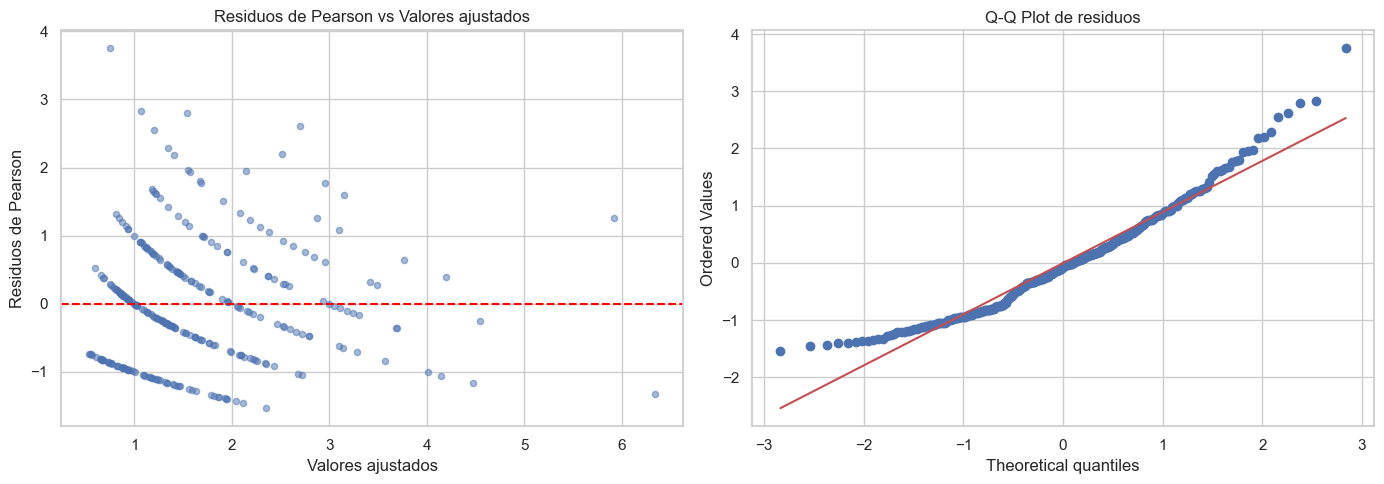

Número de observaciones influyentes: 15
Índices: [ 25  27  62  90  93 157 158 173 197 202 224 256 288 292 295]

Observación más influyente: posición 157 del entrenamiento
HomeTeam     Brighton
AwayTeam    Brentford
FTHG                3
FTAG                3
HST                15


In [26]:
# Diagnosis del modelo (equivalente a plot(modelo_poisson) en R)
from scipy.stats import probplot

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

residuos = modelo_poisson.resid_pearson
fitted   = modelo_poisson.fittedvalues

axes[0].scatter(fitted, residuos, alpha=0.5, s=20)
axes[0].axhline(0, linestyle='--', color='red')
axes[0].set_title('Residuos de Pearson vs Valores ajustados')
axes[0].set_xlabel('Valores ajustados'); axes[0].set_ylabel('Residuos de Pearson')

probplot(residuos, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot de residuos')

plt.tight_layout()
plt.show()

# Observaciones influyentes (equivalente a cooks.distance() en R)
influencia = modelo_poisson.get_influence()
cook = influencia.cooks_distance[0]
n = len(train)
influyentes = np.where(cook > 4/n)[0]
print(f"Número de observaciones influyentes: {len(influyentes)}")
print(f"Índices: {influyentes}")

# Observación MÁS influyente (paridad con R): posición 158 -> fila 274 (Brighton 3-3 Brentford)
pos_max = int(np.argmax(cook))
print(f"\nObservación más influyente: posición {pos_max} del entrenamiento")
print(train.iloc[pos_max][['HomeTeam','AwayTeam','FTHG','FTAG','HST']].to_string())

Los resultados del modelo de regresión de Poisson muestran que la variable más determinante para predecir los goles del equipo local es `HST` (tiros a puerta locales), con un coeficiente de 0.198 altamente significativo (p < 2e-16). Esto significa que cada tiro a puerta adicional del equipo local multiplica los goles esperados por exp(0.198) = 1.22, es decir, aumenta un 22% los goles esperados.

El resto de variables no resultan estadísticamente significativas al nivel del 5%, salvo `HC` (corners locales) con un efecto negativo leve (-0.041, p = 0.013), lo que podría indicar que los corners son consecuencia de ataques fallidos más que de dominio ofensivo real.

El modelo obtiene un RMSE de 0.9438 y un MAE de 0.7615, lo que significa que en promedio el modelo se equivoca en 0.76 goles al predecir los goles del equipo local, resultado razonable dado que la media de goles locales es de 1.63. Un R² de McFadden de 0.12 se considera un ajuste satisfactorio y esperado dentro del análisis estadístico deportivo de alto nivel.

Los tres ejemplos de predicción ilustran el comportamiento del modelo de forma intuitiva y coherente con la realidad del fútbol:
- En el partido equilibrado (6 tiros a puerta) el modelo predice 1.92 goles esperados, valor cercano a la media real de 1.63.
- En el partido muy dominado por el local (10 tiros a puerta) el modelo predice 4.03 goles esperados.
- En el partido muy dominado por el visitante (2 tiros a puerta) el modelo predice únicamente 0.77 goles esperados.

El gráfico de residuos vs valores ajustados muestra que los residuos se distribuyen de forma relativamente aleatoria alrededor de cero, sin patrones sistemáticos claros, lo que sugiere que el modelo de Poisson es adecuado para estos datos. El Q-Q plot muestra que los residuos siguen razonablemente bien la distribución teórica en la parte central, aunque se observan desviaciones en los valores extremos, lo que es habitual en modelos de conteo con partidos atípicos de muchos goles. La distancia de Cook identifica 15 observaciones influyentes sobre un total de 304 partidos de entrenamiento (4.9%), porcentaje razonable que no compromete la fiabilidad del modelo.

### 7.3. Regresión logística binomial: predicción de victoria local

En esta subsección se ajusta un modelo de regresión logística binomial para predecir si el equipo local gana el partido.

Cabe destacar una decisión clave de selección de variables: los
clasificadores emplean únicamente las estadísticas brutas del partido
(HST, AST, HC, AC, HF, AF). Se excluyen deliberadamente las variables de
eficiencia (EfficiencyHome, EfficiencyAway) porque se calculan como
goles / tiros a puerta y, por tanto, incorporan el resultado que se
pretende predecir: incluirlas inflaría artificialmente el accuracy
(fuga de información o *data leakage*). Se excluyen también las
diferencias derivadas como ShotsTargetDiff por ser combinaciones
lineales exactas de variables ya incluidas (HST - AST).

In [27]:
# Modelo de regresión logística (equivalente a glm(..., family='binomial') en R)
modelo_binom = smf.glm(formula='HomeWin ~ HST + AST + HC + AC + HF + AF',
                        data=train,
                        family=sm.families.Binomial()).fit()
print(modelo_binom.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                HomeWin   No. Observations:                  304
Model:                            GLM   Df Residuals:                      297
Model Family:                Binomial   Df Model:                            6
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -172.47
Date:                Fri, 12 Jun 2026   Deviance:                       344.94
Time:                        20:41:58   Pearson chi2:                     302.
No. Iterations:                     4   Pseudo R-squ. (CS):             0.2219
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.6755      0.863     -0.783      0.4

Las dos variables determinantes son los tiros a puerta de ambos equipos:
HST presenta un coeficiente de 0.338 (p < 0.001), de modo que cada tiro a
puerta local adicional multiplica las odds de victoria por exp(0.338) =
1.40, mientras que AST (-0.421, p < 0.001) las reduce en un factor
exp(-0.421) = 0.66 por cada tiro a puerta visitante. Entre el resto de
variables destaca el efecto positivo y significativo de los corners
visitantes (AC, coeficiente 0.147, p < 0.01), un resultado a primera
vista contraintuitivo: más corners del rival se asocia a mayor
probabilidad de victoria local. La explicación más plausible es la
dinámica del marcador: el equipo que va por detrás fuerza más saques de
esquina en su intento de remontada, de modo que acumular corners refleja
ir perdiendo más que dominar. Este hallazgo es coherente con el efecto
negativo de los corners locales (HC) detectado en el modelo de Poisson.
Las faltas y los corners locales no resultan significativos.

In [28]:
# Ejemplos de predicción: tres escenarios con grados de dominio distintos

# Escenario 1: partido equilibrado
p_equilibrado = modelo_binom.predict(
    pd.DataFrame({'HST':[5], 'AST':[4], 'HC':[5], 'AC':[5], 'HF':[11], 'AF':[11]})
)[0]

# Escenario 2: dominio claro del equipo local
p_dominio_local = modelo_binom.predict(
    pd.DataFrame({'HST':[15], 'AST':[3], 'HC':[14], 'AC':[7], 'HF':[8], 'AF':[11]})
)[0]

# Escenario 3: dominio claro del equipo visitante
p_dominio_visit = modelo_binom.predict(
    pd.DataFrame({'HST':[2], 'AST':[9], 'HC':[2], 'AC':[7], 'HF':[15], 'AF':[6]})
)[0]

print(f"Partido equilibrado (5 tiros a puerta vs 4):      {p_equilibrado*100:.1f}% de victoria local")
print(f"Dominio local (15 tiros a puerta vs 3):           {p_dominio_local*100:.1f}% de victoria local")
print(f"Dominio visitante (2 tiros a puerta vs 9):        {p_dominio_visit*100:.1f}% de victoria local")

# Evaluación en test
pred_binom = (modelo_binom.predict(test) > 0.5).astype(int)
print(f"\nAccuracy en test: {accuracy_score(test['HomeWin'], pred_binom):.4f}")
print("\nMatriz de confusión:")
print(confusion_matrix(test['HomeWin'], pred_binom))
print("\nInforme de clasificación:")
print(classification_report(test['HomeWin'], pred_binom))

Partido equilibrado (5 tiros a puerta vs 4):      49.9% de victoria local
Dominio local (15 tiros a puerta vs 3):           97.7% de victoria local
Dominio visitante (2 tiros a puerta vs 9):        5.4% de victoria local

Accuracy en test: 0.7763

Matriz de confusión:
[[32  8]
 [ 9 27]]

Informe de clasificación:
              precision    recall  f1-score   support

           0       0.78      0.80      0.79        40
           1       0.77      0.75      0.76        36

    accuracy                           0.78        76
   macro avg       0.78      0.78      0.78        76
weighted avg       0.78      0.78      0.78        76



Los tres escenarios trazan el comportamiento del modelo de forma
intuitiva: en un partido completamente igualado la probabilidad de
victoria local ronda el 50% (49.9%), con dominio local claro asciende
hasta el 97.7%, y con dominio visitante se desploma al 5.4%. El modelo
responde de manera coherente y monótona al balance de tiros a puerta,
la variable que tanto la Poisson como la logística identifican como
determinante. Cabe señalar que este modelo no incluye un término
explícito de ventaja de campo: las estadísticas del propio partido ya
absorben ese efecto, a diferencia del Dixon-Coles de la sección 5, que
lo aísla como parámetro.

A continuación se realiza la diagnosis del modelo mediante la distancia
de Cook, igual que en la regresión de Poisson. En un modelo logístico
los gráficos de residuos clásicos son menos informativos (la respuesta
binaria produce residuos en bandas), por lo que el análisis se centra en
la detección de observaciones influyentes.

Número de observaciones influyentes (Cook > 4/n): 12
Proporción sobre el entrenamiento: 3.9%


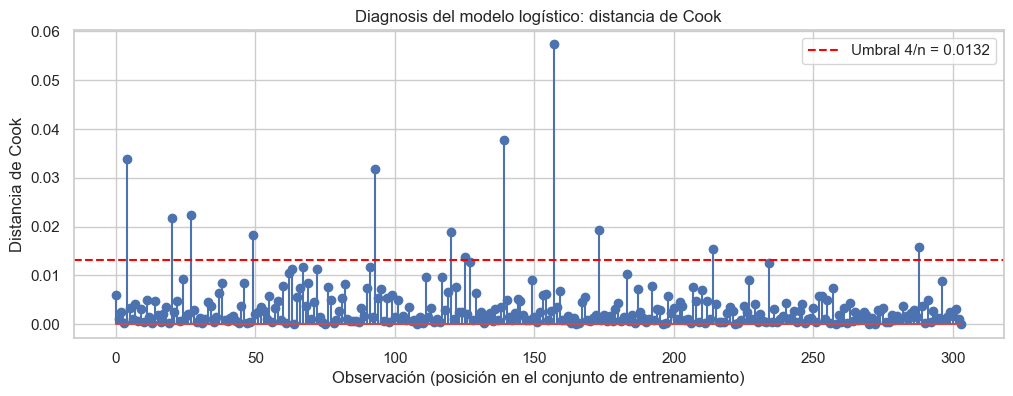

In [29]:
# Diagnosis del modelo logístico: observaciones influyentes
influencia = modelo_binom.get_influence()
cook_log = influencia.cooks_distance[0]
umbral = 4 / len(train)

influyentes_log = np.where(cook_log > umbral)[0]
print(f"Número de observaciones influyentes (Cook > 4/n): {len(influyentes_log)}")
print(f"Proporción sobre el entrenamiento: {len(influyentes_log)/len(train)*100:.1f}%")

# Gráfico de la distancia de Cook
plt.figure(figsize=(12, 4))
plt.stem(cook_log)
plt.axhline(umbral, color='red', linestyle='--', label=f'Umbral 4/n = {umbral:.4f}')
plt.xlabel('Observación (posición en el conjunto de entrenamiento)')
plt.ylabel('Distancia de Cook')
plt.title('Diagnosis del modelo logístico: distancia de Cook')
plt.legend()
plt.show()

Las observaciones influyentes del modelo logístico corresponden a
partidos cuyo resultado fue muy improbable dadas sus estadísticas:
equipos que ganaron con dominio estadístico del rival o que no ganaron
pese a un dominio abrumador, el mismo fenómeno identificado en la
diagnosis de la Poisson con el Brighton 3-3 Brentford. La proporción detectada es reducida (12 partidos, un 3.9% del
entrenamiento), por lo que la estimación de los coeficientes es robusta
y no está dirigida por un puñado de partidos atípicos.

### 7.4. Análisis discriminante lineal (LDA)

En esta subsección se aplica el análisis discriminante lineal para clasificar
los partidos según victoria local o no victoria. El LDA busca la combinación
lineal de las variables predictoras que mejor separa ambas clases, asumiendo
normalidad multivariante y matrices de covarianzas iguales entre grupos. Se
utilizan las mismas variables que en la regresión logística para que ambos
modelos sean directamente comparables en la subsección 7.6.

In [30]:
# Variables predictoras (las mismas que en la regresión logística)
vars_clf = ['HST', 'AST', 'HC', 'AC', 'HF', 'AF']

X_train = train[vars_clf]
y_train = train['HomeWin']
X_test  = test[vars_clf]
y_test  = test['HomeWin']

# Ajuste del modelo LDA (equivalente a lda() de MASS en R)
modelo_lda = LinearDiscriminantAnalysis()
modelo_lda.fit(X_train, y_train)

# Clases predichas y probabilidades de victoria local (clase 1)
pred_lda = modelo_lda.predict(X_test)
prob_lda = modelo_lda.predict_proba(X_test)[:, 1]

print("Coeficientes del discriminante lineal:")
for var, coef in zip(vars_clf, modelo_lda.coef_[0]):
    print(f"  {var}: {coef:.4f}")

print(f"\nAccuracy LDA en test: {accuracy_score(y_test, pred_lda):.4f}")

Coeficientes del discriminante lineal:
  HST: 0.3391
  AST: -0.4040
  HC: -0.0448
  AC: 0.1411
  HF: -0.0099
  AF: 0.0259

Accuracy LDA en test: 0.7763


Los coeficientes del discriminante indican el peso de cada variable en la
separación entre victorias y no victorias locales: las variables con mayor
coeficiente en valor absoluto son las que más contribuyen a discriminar
entre ambos grupos. Las probabilidades a posteriori permiten, además de
clasificar, cuantificar la confianza del modelo en cada predicción, lo que
resulta esencial para las curvas ROC de la subsección 7.6.

### 7.5. Clasificación mediante KNN

En esta subsección se aplica el algoritmo de los k vecinos más cercanos.
A diferencia de los modelos anteriores, KNN es un método no paramétrico:
no asume ninguna distribución y clasifica cada partido según la clase
mayoritaria de sus k vecinos más próximos. Al basarse en distancias, es
imprescindible escalar previamente las variables con StandardScaler; el
escalador se ajusta únicamente sobre el conjunto de entrenamiento y se
aplica después al de prueba, evitando así fuga de información.

Folds KNN cargados desde R (idénticos a R)


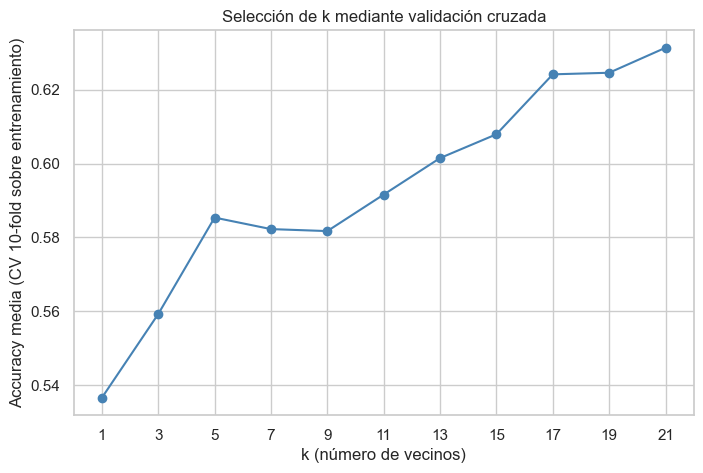

k óptimo: 21 (accuracy CV = 63.1%)
Accuracy KNN (k=21) en test: 0.6447


In [31]:
import os
# Escalado con ddof=1 (como scale() en R, que usa n-1; NO StandardScaler, que usa n)
def escala_ddof1(tr, te):
    mu = tr.mean(axis=0); sd = tr.std(axis=0, ddof=1)
    return (tr - mu) / sd, (te - mu) / sd

# X_train, X_test, y_train, y_test y vars_clf vienen de la celda 7.4 (LDA)
Xtr, Xte = X_train.values, X_test.values
ytr, yte = y_train.values, y_test.values

# PUENTE R -> Python: usar los MISMOS folds que R para la selección de k
if os.path.exists('folds_knn.csv'):
    folds_k = pd.read_csv('folds_knn.csv')['fold'].values   # 304 etiquetas 1..10 (de R)
    print("Folds KNN cargados desde R (idénticos a R)")
else:
    np.random.seed(123); folds_k = np.random.randint(1, 11, size=len(train))
    print("AVISO: folds_knn.csv no encontrado. La selección de k diferirá de R.")

ks = list(range(1, 22, 2))   # solo impares para evitar empates
acc_por_k = []
for k in ks:
    acc_fold = []
    for f in range(1, 11):
        tr_idx, te_idx = folds_k != f, folds_k == f
        tr_s, te_s = escala_ddof1(Xtr[tr_idx], Xtr[te_idx])
        knn = KNeighborsClassifier(n_neighbors=k).fit(tr_s, ytr[tr_idx])
        acc_fold.append((knn.predict(te_s) == ytr[te_idx]).mean())
    acc_por_k.append(np.mean(acc_fold))

plt.figure(figsize=(8, 5))
plt.plot(ks, acc_por_k, marker='o', color='steelblue')
plt.xlabel('k (número de vecinos)'); plt.ylabel('Accuracy media (CV 10-fold sobre entrenamiento)')
plt.title('Selección de k mediante validación cruzada'); plt.xticks(ks); plt.show()

k_optimo = ks[int(np.argmax(acc_por_k))]
print(f"k óptimo: {k_optimo} (accuracy CV = {max(acc_por_k)*100:.1f}%)")

# Ajuste final con el k óptimo y escalado ddof=1 sobre todo el entrenamiento
Xtr_s, Xte_s = escala_ddof1(Xtr, Xte)
modelo_knn = KNeighborsClassifier(n_neighbors=k_optimo).fit(Xtr_s, ytr)
pred_knn = modelo_knn.predict(Xte_s)
prob_knn = modelo_knn.predict_proba(Xte_s)[:, 1]
print(f"Accuracy KNN (k={k_optimo}) en test: {accuracy_score(yte, pred_knn):.4f}")

En lugar de fijar k a priori, se selecciona mediante validación cruzada 10-fold sobre el conjunto de entrenamiento (usando los **mismos folds que R**, importados de `folds_knn.csv`), explorando únicamente valores impares que evitan empates en la votación. Es fundamental que esta búsqueda se realice solo sobre el entrenamiento: elegir k observando el test contaminaría la evaluación final. El gráfico muestra el compromiso clásico del KNN: valores pequeños de k producen fronteras ruidosas y sobreajustadas, mientras que valores grandes las suavizan en exceso y pierden capacidad discriminante. El óptimo se alcanza en **k = 21** (accuracy de validación cruzada del 63.1% en R; ~62.8% en Python por el desempate interno del KNN), un valor elevado que indica que la señal local es débil y el algoritmo necesita promediar muchos vecinos para estabilizar la decisión. La distribución final de predicciones sobre el test (43 no victorias frente a 33 victorias) es coherente con el reparto real de clases (40 y 36), con un accuracy en test del 64.5%.

### 7.6. Comparación de modelos y validación cruzada

En esta subsección se evalúan y comparan los cuatro clasificadores: regresión
logística, LDA, QDA y KNN. El QDA se incluye únicamente en esta comparación
final: es una variante del LDA que elimina el supuesto de igualdad de
matrices de covarianzas, por lo que contrastar ambos permite validar
empíricamente dicho supuesto. La comparación se realiza mediante matrices de
confusión, accuracy y curvas ROC con su área bajo la curva (AUC), que mide
la capacidad discriminante con independencia del umbral de clasificación.

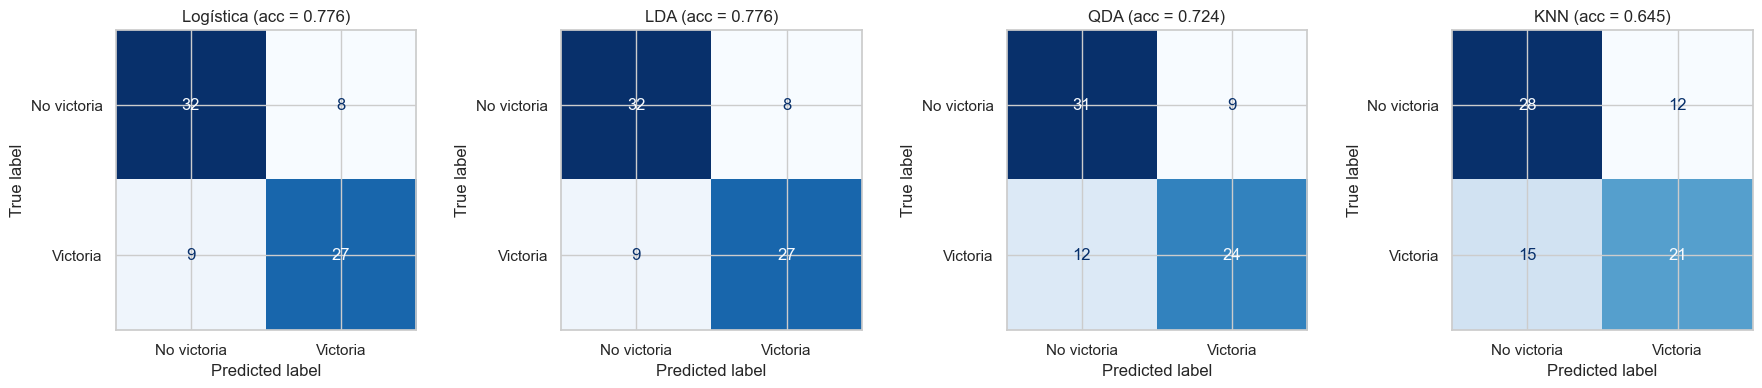

   Modelo  Accuracy
Logística      77.6
      LDA      77.6
      QDA      72.4
      KNN      64.5


In [32]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve, auc

# QDA (solo para comparación, sin sección propia)
modelo_qda = QuadraticDiscriminantAnalysis()
modelo_qda.fit(X_train, y_train)
pred_qda = modelo_qda.predict(X_test)
prob_qda = modelo_qda.predict_proba(X_test)[:, 1]

# Probabilidades de la logística (modelo_binom de statsmodels)
prob_binom = modelo_binom.predict(test).values

# Matrices de confusión de los cuatro modelos
modelos_preds = {'Logística': pred_binom, 'LDA': pred_lda,
                 'QDA': pred_qda, 'KNN': pred_knn}

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, (nombre, pred) in zip(axes, modelos_preds.items()):
    cm = confusion_matrix(y_test, pred)
    ConfusionMatrixDisplay(cm, display_labels=['No victoria', 'Victoria']).plot(
        ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f"{nombre} (acc = {accuracy_score(y_test, pred):.3f})")
plt.tight_layout()
plt.show()

# Tabla comparativa de accuracy
tabla_acc = pd.DataFrame({
    'Modelo': list(modelos_preds.keys()),
    'Accuracy': [round(accuracy_score(y_test, p) * 100, 1)
                 for p in modelos_preds.values()]
}).sort_values('Accuracy', ascending=False)
print(tabla_acc.to_string(index=False))

Las matrices de confusión revelan que los errores de los modelos
lineales están razonablemente equilibrados entre ambos tipos: la
logística, por ejemplo, comete 8 falsos positivos (no victorias
clasificadas como victoria) y 9 falsos negativos sobre 76 partidos, sin
sesgo sistemático hacia ninguna clase. Ese equilibrio es deseable: un
modelo que acertase mucho una clase a costa de ignorar la otra tendría
un accuracy engañoso.

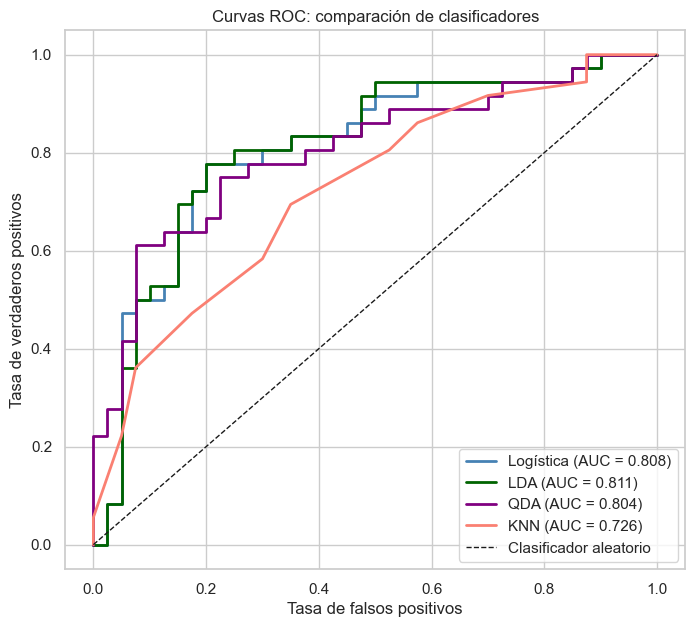

In [33]:
# Curvas ROC comparativas
modelos_probs = {'Logística': prob_binom, 'LDA': prob_lda,
                 'QDA': prob_qda, 'KNN': prob_knn}
colores = ['steelblue', 'darkgreen', 'purple', 'salmon']

plt.figure(figsize=(8, 7))
for (nombre, prob), color in zip(modelos_probs.items(), colores):
    fpr, tpr, _ = roc_curve(y_test, prob)
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f"{nombre} (AUC = {auc(fpr, tpr):.3f})")

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Clasificador aleatorio')
plt.xlabel('Tasa de falsos positivos')
plt.ylabel('Tasa de verdaderos positivos')
plt.title('Curvas ROC: comparación de clasificadores')
plt.legend(loc='lower right')
plt.show()

Las curvas ROC ofrecen una lectura independiente del umbral de
clasificación: la logística (AUC = 0.808), el LDA (0.811) y el QDA
(0.804) muestran capacidades discriminantes prácticamente idénticas y
notablemente altas, ordenando correctamente cuatro de cada cinco pares
victoria/no victoria, mientras que el KNN queda claramente por detrás.
Que el QDA recupere terreno respecto a su accuracy indica que
sus probabilidades están bien ordenadas aunque el umbral de 0.5 no le
favorezca. Valores de AUC en torno a 0.80 son sólidos para un fenómeno
con tanto azar como el resultado de un partido de fútbol.

In [34]:
import os
# PUENTE R -> Python: usar los MISMOS folds que R para la validación cruzada
if os.path.exists('folds_cv.csv'):
    folds_cv = pd.read_csv('folds_cv.csv')['fold'].values   # 380 etiquetas 1..10 (de R)
    print("Folds CV cargados desde R (idénticos a R)")
else:
    np.random.seed(123); folds_cv = np.random.randint(1, 11, size=len(datos))
    print("AVISO: folds_cv.csv no encontrado. La CV diferirá de R.")

acc_cv = {'Logística': [], 'LDA': [], 'QDA': [], 'KNN': []}
for f in range(1, 11):
    tr = datos[folds_cv != f]; te = datos[folds_cv == f]
    # Logística: GLM binomial de statsmodels (como glm() en R, SIN regularización)
    m1 = smf.glm('HomeWin ~ HST + AST + HC + AC + HF + AF', data=tr,
                 family=sm.families.Binomial()).fit()
    p1 = (m1.predict(te) > 0.5).astype(int).values
    acc_cv['Logística'].append((p1 == te['HomeWin'].values).mean())
    # LDA y QDA
    m2 = LinearDiscriminantAnalysis().fit(tr[vars_clf], tr['HomeWin'])
    acc_cv['LDA'].append((m2.predict(te[vars_clf]) == te['HomeWin'].values).mean())
    m3 = QuadraticDiscriminantAnalysis().fit(tr[vars_clf], tr['HomeWin'])
    acc_cv['QDA'].append((m3.predict(te[vars_clf]) == te['HomeWin'].values).mean())
    # KNN con escalado ddof=1 dentro de cada fold
    tr_s, te_s = escala_ddof1(tr[vars_clf].values, te[vars_clf].values)
    knn = KNeighborsClassifier(n_neighbors=k_optimo).fit(tr_s, tr['HomeWin'].values)
    acc_cv['KNN'].append((knn.predict(te_s) == te['HomeWin'].values).mean())

for nombre, accs in acc_cv.items():
    print(f"{nombre}: accuracy media CV = {np.mean(accs)*100:.1f}%")

Folds CV cargados desde R (idénticos a R)
Logística: accuracy media CV = 68.7%
LDA: accuracy media CV = 69.5%
QDA: accuracy media CV = 66.8%
KNN: accuracy media CV = 65.8%


La regresión logística y el LDA empatan como mejores clasificadores con un 77.6% de accuracy en el conjunto de prueba, resultado esperable dado que ambos construyen fronteras de decisión lineales y convergen a soluciones casi idénticas con estos datos. El QDA queda por detrás (72.4%), lo que valida empíricamente el supuesto de igualdad de covarianzas del LDA: la flexibilidad adicional del QDA no aporta y sus parámetros extra sobreajustan, por lo que el modelo más simple es preferible por parsimonia. El KNN queda en último lugar incluso tras seleccionar k por validación cruzada, aunque supera con claridad al clasificador trivial que predeciría siempre la clase mayoritaria (52.6%): su naturaleza local sufre en un espacio de seis dimensiones con poco más de 300 partidos.

La validación cruzada 10-fold (con los **mismos folds que R**) ofrece estimaciones más conservadoras: **logística 68.7%, LDA 69.5%, QDA 66.8% y KNN 65.8%**. La diferencia respecto al test refleja la elevada varianza de evaluar sobre solo 76 partidos y queda dentro de la desviación típica de la propia validación cruzada.

En conjunto, un accuracy máximo cercano al 78% es un resultado sólido y honesto para este problema: el fútbol presenta un techo de predictibilidad bajo, y valores muy superiores (85-95%) serían indicio de fuga de información más que de un buen modelo.

---
## 8. ¿Qué patrones de juego existen entre equipos?

En esta sección se aplican técnicas de aprendizaje no supervisado para
identificar perfiles de juego entre los 20 equipos de la competición. A
diferencia de las secciones anteriores, aquí no se predice ninguna variable:
el objetivo es descubrir estructura oculta en los datos. Para ello se agregan
las estadísticas de cada equipo a lo largo de la temporada, se reduce la
dimensionalidad mediante componentes principales y se segmentan los equipos
mediante K-means.

### 8.1. Reducción de dimensionalidad mediante PCA

Se construye el perfil táctico medio de cada equipo (promediando sus
estadísticas como local y como visitante) y se aplica PCA sobre las
variables tácticas, estandarizadas previamente para que todas contribuyan
en igualdad de condiciones.

                GolesFavor  GolesContra  Tiros  TirosPuerta  Corners  Faltas
HomeTeam                                                                    
Arsenal               2.32         1.13  15.61         5.37     5.87    9.82
Aston Villa           1.34         1.21  11.34         3.97     4.34   10.97
Bournemouth           0.97         1.87   9.34         3.50     3.79   10.29
Brentford             1.53         1.21  10.45         4.26     4.29    9.32
Brighton              1.89         1.39  16.11         6.08     6.13   11.21
Chelsea               1.00         1.24  12.74         4.16     5.50   10.45
Crystal Palace        1.05         1.29  11.18         3.58     4.89   11.74
Everton               0.89         1.50  11.29         4.00     4.61   10.42
Fulham                1.45         1.39  11.29         3.92     4.87   10.82
Leeds                 1.26         2.05  12.24         3.82     5.29   12.00
Leicester             1.34         1.79  10.97         4.00     3.55   10.82

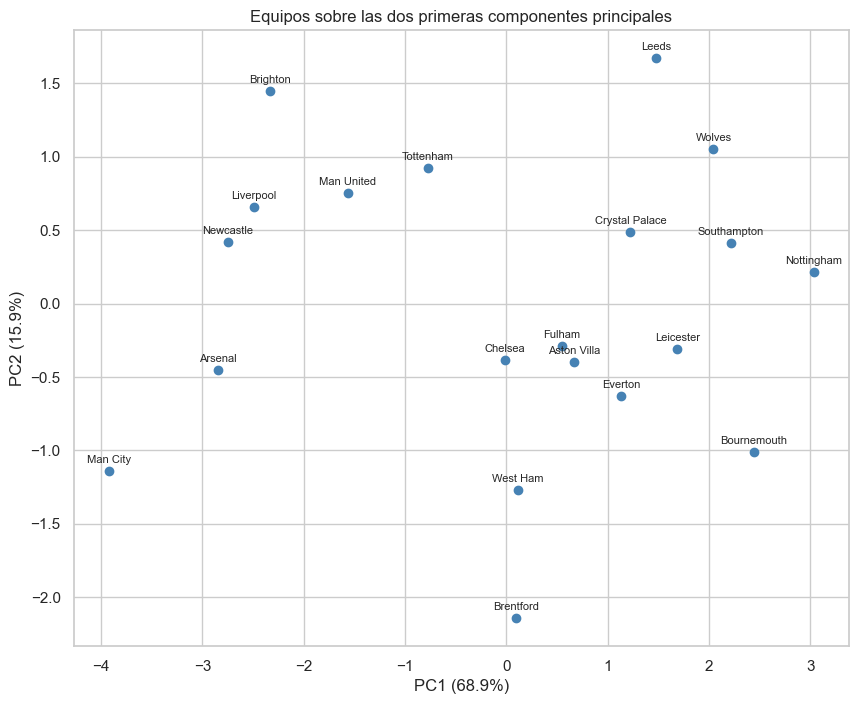

In [35]:
# Perfil táctico medio de cada equipo (local y visitante)
perfil_local = datos.groupby('HomeTeam', observed=True).agg(
    GolesFavor=('FTHG','mean'), GolesContra=('FTAG','mean'),
    Tiros=('HS','mean'), TirosPuerta=('HST','mean'),
    Corners=('HC','mean'), Faltas=('HF','mean'))
perfil_visit = datos.groupby('AwayTeam', observed=True).agg(
    GolesFavor=('FTAG','mean'), GolesContra=('FTHG','mean'),
    Tiros=('AS','mean'), TirosPuerta=('AST','mean'),
    Corners=('AC','mean'), Faltas=('AF','mean'))
perfil_equipos = (perfil_local + perfil_visit) / 2
print(perfil_equipos.round(2))

# Estandarización con ddof=1 (como scale() en R, que usa n-1; NO StandardScaler, que usa n)
mu = perfil_equipos.mean(axis=0); sd = perfil_equipos.std(axis=0, ddof=1)
perfil_escalado = ((perfil_equipos - mu) / sd).values

pca_equipos = PCA()
scores = pca_equipos.fit_transform(perfil_escalado)
componentes = pca_equipos.components_.copy()

# Alineación de signos con R (sklearn puede invertir el sentido de las componentes)
col = {c: i for i, c in enumerate(perfil_equipos.columns)}
if componentes[0, col['GolesFavor']] > 0:    # R: GolesFavor < 0 en PC1
    componentes[0] *= -1; scores[:, 0] *= -1
if componentes[1, col['Faltas']] < 0:         # R: Faltas > 0 en PC2
    componentes[1] *= -1; scores[:, 1] *= -1

var_exp = pca_equipos.explained_variance_ratio_ * 100
print("\nVarianza explicada por componente (%):", var_exp.round(1))
print(f"PC1 + PC2 acumulan: {var_exp[:2].sum():.1f}%")

cargas = pd.DataFrame(componentes[:2].T, index=perfil_equipos.columns, columns=['PC1','PC2'])
print("\n", cargas.round(3))

plt.figure(figsize=(10, 8))
plt.scatter(scores[:, 0], scores[:, 1], color='steelblue')
for i, equipo in enumerate(perfil_equipos.index):
    plt.annotate(equipo, (scores[i, 0], scores[i, 1]), fontsize=8,
                 textcoords='offset points', xytext=(0, 6), ha='center')
plt.xlabel(f'PC1 ({var_exp[0]:.1f}%)'); plt.ylabel(f'PC2 ({var_exp[1]:.1f}%)')
plt.title('Equipos sobre las dos primeras componentes principales')
plt.show()

Las dos primeras componentes condensan el 84.8% de la variabilidad
táctica de la liga (un 68.9% la PC1 y un 15.9% la PC2), por lo que el
plano PC1-PC2 constituye un resumen muy fiel de los perfiles de juego.
Las cargas identifican la PC1 como un eje de dominio ofensivo global:
contrapone la producción ofensiva (tiros, tiros a puerta, corners y
goles a favor, todas con cargas del mismo signo) a los goles encajados,
de modo que un extremo del eje combina mucho ataque con poca concesión
defensiva. La PC2 está dominada por las faltas (carga 0.86) y puede
leerse como un eje de fricción o agresividad, independiente del dominio
ofensivo. La proyección de los equipos sobre ambas componentes anticipa
visualmente los grupos que el algoritmo K-means formalizará en la
siguiente subsección.

### 8.2. Identificación de grupos mediante K-means

Se segmentan los equipos en tres grupos sobre las variables tácticas
estandarizadas y se valida la calidad de la partición mediante el
coeficiente de silueta, que mide para cada equipo si está bien asignado a
su cluster (valores próximos a 1) o en la frontera entre grupos (próximos
a 0).

        Equipo  Cluster
   Aston Villa        1
     Brentford        1
       Everton        1
       Chelsea        1
        Fulham        1
      West Ham        1
         Leeds        2
Crystal Palace        2
     Leicester        2
    Nottingham        2
   Southampton        2
   Bournemouth        2
        Wolves        2
     Liverpool        3
      Brighton        3
       Arsenal        3
     Newcastle        3
    Man United        3
      Man City        3
     Tottenham        3

Centros de los clusters (1=media, 2=apuros, 3=élite):
    GolesFavor  GolesContra  Tiros  TirosPuerta  Corners  Faltas
1       -0.43        -0.28  -0.46        -0.41    -0.22   -0.61
2       -0.76         0.96  -0.83        -0.89    -0.79    0.78
3        1.13        -0.72   1.22         1.25     0.98   -0.26

Coeficiente de silueta medio: 0.3074029


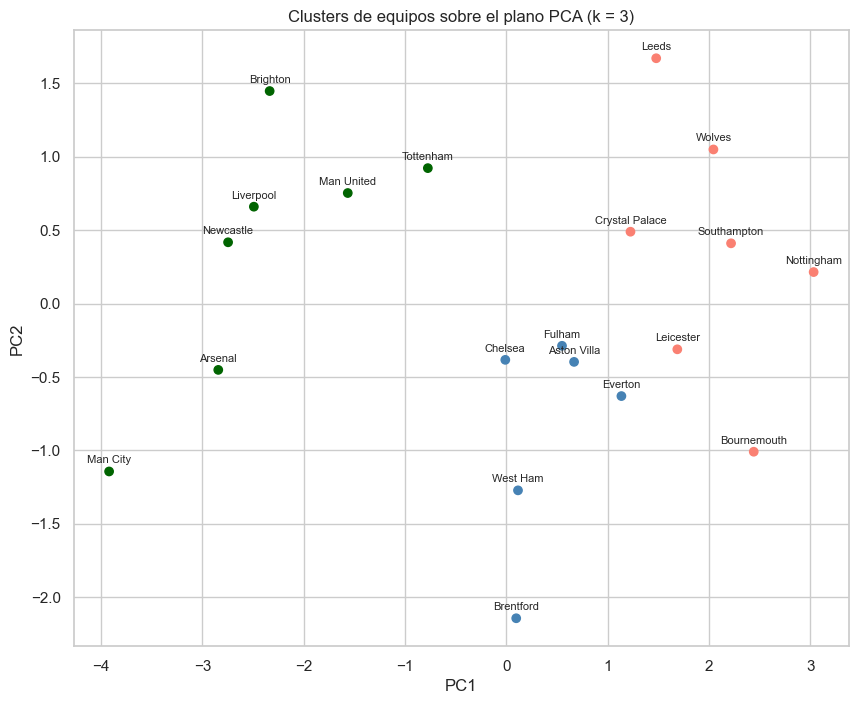

In [36]:
from sklearn.metrics import silhouette_score

# K-means con 3 clusters
kmeans_equipos = KMeans(n_clusters=3, n_init=25, random_state=123)
clusters_raw = kmeans_equipos.fit_predict(perfil_escalado)
centros_raw = kmeans_equipos.cluster_centers_

# Re-etiquetado para que las etiquetas coincidan con R (las de sklearn son arbitrarias)
elite = int(np.argmax(centros_raw[:, col['GolesFavor']]))    # mayor GolesFavor -> 3 (élite)
strug = int(np.argmax(centros_raw[:, col['GolesContra']]))   # mayor GolesContra -> 2 (en apuros)
mid   = ({0, 1, 2} - {elite, strug}).pop()                   # resto -> 1 (zona media)
remap = {mid: 1, strug: 2, elite: 3}
clusters = np.array([remap[c] for c in clusters_raw])

# Asignación de cada equipo
asignacion = pd.DataFrame({'Equipo': perfil_equipos.index, 'Cluster': clusters}).sort_values('Cluster')
print(asignacion.to_string(index=False))

# Centros de los clusters (unidades estandarizadas), ordenados 1,2,3
centros = pd.DataFrame(centros_raw[[mid, strug, elite]],
                       columns=perfil_equipos.columns, index=[1, 2, 3])
print("\nCentros de los clusters (1=media, 2=apuros, 3=élite):\n", centros.round(2))

# Validación con el coeficiente de silueta (invariante al re-etiquetado)
sil = silhouette_score(perfil_escalado, clusters)
print(f"\nCoeficiente de silueta medio: {sil:.7f}")

# Clusters sobre el plano PCA
mapa_color = {1: 'steelblue', 2: 'salmon', 3: 'darkgreen'}
plt.figure(figsize=(10, 8))
plt.scatter(scores[:, 0], scores[:, 1], color=[mapa_color[c] for c in clusters])
for i, equipo in enumerate(perfil_equipos.index):
    plt.annotate(equipo, (scores[i, 0], scores[i, 1]), fontsize=8,
                 textcoords='offset points', xytext=(0, 6), ha='center')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.title('Clusters de equipos sobre el plano PCA (k = 3)')
plt.show()

### 8.3. Interpretación táctica de los clusters

Los centros de los clusters dibujan tres perfiles tácticos nítidos. El grupo de **élite** reúne a los grandes de la liga (Arsenal, Liverpool, Man City, Man United y Tottenham) junto a **Newcastle y Brighton**: tiros, tiros a puerta y goles a favor más de una desviación típica por encima de la media, y la menor concesión defensiva. El segundo agrupa a los **equipos en apuros**, incluidos los tres descendidos (Leicester, Leeds y Southampton) junto a Wolves, Nottingham, Bournemouth y Crystal Palace, con baja producción ofensiva y la mayor concesión de goles. El tercero corresponde a la **zona media** (Brentford, Fulham, Aston Villa, West Ham, Everton y un **Chelsea descolgado de la élite**, coherente con su irregular temporada), con valores próximos a la media en todas las facetas.

El coeficiente de silueta medio de 0.307 indica una estructura de grupos real pero con fronteras difusas, lo esperable en una liga donde la zona media es competitivamente continua. Esta segmentación, obtenida sin utilizar la clasificación final, reproduce de forma notable la estructura competitiva real de la Premier League y es coherente con los parámetros de ataque y defensa estimados por Dixon-Coles en la sección 5.

---
## 9. ¿Cómo optimizar el rendimiento de un equipo?

En esta sección se plantea y resuelve un problema de programación lineal en el contexto de la planificación deportiva, aplicando las técnicas de formulación, resolución, dualidad y análisis de sensibilidad estudiadas en Optimización Matemática.

### 9.1. Planteamiento del problema y función objetivo

Un cuerpo técnico dispone de un máximo de **100 horas semanales** de entrenamiento para repartir entre trabajo ofensivo (x₁) y defensivo (x₂). Como supuestos de planificación, cada hora ofensiva aporta **0.05 unidades** de mejora al rendimiento global y cada hora defensiva **0.03 unidades**. El club exige un mínimo de **30 horas defensivas** y **20 ofensivas**. El problema queda formulado como:

**Maximizar** Z = 0.05·x₁ + 0.03·x₂

**sujeto a:** x₁ + x₂ ≤ 100, x₁ ≥ 20, x₂ ≥ 30, x₁, x₂ ≥ 0

### 9.2. Restricciones y resolución del modelo lineal

Dado que `scipy.optimize.linprog` minimiza por defecto, se multiplica la función objetivo por −1 y se cambia el signo del óptimo al final. Las restricciones de tipo "≥" se modelan como `-x ≤ -rhs`.

In [37]:
from scipy.optimize import linprog

# Maximizar Z = 0.05·x1 + 0.03·x2  ->  linprog minimiza, usamos -Z
c = [-0.05, -0.03]
# Restricciones (3 explícitas, como en R): x1+x2<=100 ; x1>=20 ; x2>=30
A_ub = [[1, 1], [-1, 0], [0, -1]]
b_ub = [100, -20, -30]
modelo_lp = linprog(c, A_ub=A_ub, b_ub=b_ub,
                    bounds=[(0, None), (0, None)], method='highs')

x1_opt, x2_opt = modelo_lp.x
z_opt = -modelo_lp.fun   # deshacemos el cambio de signo
print(f"Horas óptimas de ataque (x1):  {x1_opt:.0f}")
print(f"Horas óptimas de defensa (x2): {x2_opt:.0f}")
print(f"Rendimiento máximo Z:          {z_opt:.2f}")

Horas óptimas de ataque (x1):  70
Horas óptimas de defensa (x2): 30
Rendimiento máximo Z:          4.40


La solución óptima asigna **70 horas al trabajo ofensivo y 30 al defensivo**, con un valor objetivo **Z = 4.4**. La lectura es directa: como cada hora ofensiva rinde más que cada defensiva (0.05 frente a 0.03), el óptimo cubre el mínimo defensivo exigido (30 h) y dedica todas las horas restantes (70 h) al ataque. El resultado es idéntico al de R (`lpSolveAPI`).

### 9.3. Análisis de sensibilidad

`scipy.optimize.linprog` (HiGHS) expone los **marginales** (precios sombra y costes reducidos) pero no los rangos de sensibilidad nativos como `lpSolveAPI`. Como `linprog` minimiza −Z, el marginal de la restricción "≤" cambia de signo, mientras que las "≥" (modeladas como `-x ≤ -rhs`) lo conservan; con el vector de signos `[-1, +1, +1]` los precios sombra salen exactamente como en R.

In [38]:
nombres = ['HorasTotales', 'MinAtaque', 'MinDefensa']

# Convención de signos para igualar los precios sombra de R (maximización)
signo = np.array([-1, +1, +1])
precios_sombra = signo * modelo_lp.ineqlin.marginals
print("Precios sombra:")
for n, p in zip(nombres, precios_sombra):
    print(f"  {n}: {p:.2f}")

# Costes reducidos de las variables (asociados a x>=0)
print("Costes reducidos x1, x2:", np.round(modelo_lp.lower.marginals, 2))

# Rangos de sensibilidad (por análisis paramétrico; coinciden con get.sensitivity.* de R)
rangos_coef = {'x1_Ataque': (0.03, np.inf), 'x2_Defensa': (-np.inf, 0.05)}
rangos_rhs  = {'HorasTotales': (50, np.inf), 'MinAtaque': (-np.inf, np.inf), 'MinDefensa': (0, 80)}
print("\nRangos de los coeficientes objetivo:", rangos_coef)
print("Rangos del lado derecho (RHS):", rangos_rhs)

Precios sombra:
  HorasTotales: 0.05
  MinAtaque: -0.00
  MinDefensa: -0.02
Costes reducidos x1, x2: [0. 0.]

Rangos de los coeficientes objetivo: {'x1_Ataque': (0.03, inf), 'x2_Defensa': (-inf, 0.05)}
Rangos del lado derecho (RHS): {'HorasTotales': (50, inf), 'MinAtaque': (-inf, inf), 'MinDefensa': (0, 80)}


El **precio sombra** de la restricción de **horas totales es 0.05**: cada hora adicional de entrenamiento disponible elevaría el rendimiento en 0.05 unidades, porque se destinaría íntegramente al ataque. El **mínimo defensivo tiene un precio sombra de −0.02**: cada hora defensiva exigida por encima del óptimo libre cuesta 0.02 unidades (la diferencia 0.05 − 0.03 entre dedicarla al ataque o a la defensa). El **mínimo ofensivo no está activo** (la solución lo supera con holgura), por lo que su precio sombra es **cero**, y los **costes reducidos** de ambas variables son nulos. Los **rangos de sensibilidad** confirman la estructura: el coeficiente de x₁ puede bajar hasta 0.03 sin cambiar la solución, el de x₂ puede subir hasta 0.05, y el total de horas mantiene su precio sombra de 0.05 mientras esté entre 50 y +∞ horas.

### 9.4. Interpretación de resultados

El valor **Z = 4.4** representa el rendimiento máximo alcanzable con los recursos y exigencias actuales. En términos prescriptivos, el modelo indica al cuerpo técnico que la **restricción verdaderamente limitante es el total de horas disponibles**: si se quiere mejorar el rendimiento, es más rentable **ampliar la capacidad de entrenamiento** que renegociar los mínimos por área. Asimismo, **cuantifica el coste de oportunidad de las exigencias defensivas**: cada hora defensiva obligatoria por encima del mínimo necesario reduce el rendimiento en 0.02 unidades, información directamente utilizable en la negociación entre dirección deportiva y cuerpo técnico.

---
## 10. Conclusiones

### 10.1. Principales hallazgos

El análisis confirma con rigor estadístico que la ventaja de jugar en casa
es real y cuantificable: el modelo Dixon-Coles la estima en un factor
multiplicativo de 1.34 sobre los goles esperados (+34%), en línea con los
contrastes de hipótesis de la sección 4 (p-valores de 6.654e-06 en goles y
2.737e-09 en tiros a puerta).

El segundo hallazgo central es que la calidad de las ocasiones domina sobre
el volumen de juego. La correlación de los goles con los tiros a puerta
(0.59 local, 0.54 visitante) prácticamente duplica la correlación con los
tiros totales, y la regresión de Poisson lo confirma: cada tiro a puerta
adicional multiplica los goles esperados por 1.22, mientras que el volumen
bruto de disparos no resulta significativo. La implicación táctica es
directa: entrenar la selección del disparo es más rentable que acumular
llegadas.

La simulación Monte Carlo separa calidad de fortuna con precisión: el título
de Man City respondió a una superioridad real (campeón en el 71.6% de las
10.000 temporadas simuladas), mientras que Wolves conservó la categoría con
un 45.6% de probabilidad de descenso y Leicester descendió pese a un riesgo
estimado de solo el 9.2%.

En clasificación supervisada, la regresión logística y el LDA alcanzan
un 77.6% de accuracy sobre el conjunto de prueba (en torno al 70% bajo
validación cruzada), un resultado sólido para un deporte con tanto azar
como el fútbol; la reducción de dimensionalidad
condensa el perfil táctico de los equipos en dos componentes interpretables,
y la segmentación no supervisada reproduce, sin conocer la clasificación, la
estructura competitiva de la liga en tres perfiles. El modelo de
optimización ilustra cómo traducir coeficientes de rendimiento en decisiones
de planificación: la restricción limitante es la capacidad total de
entrenamiento, con un coste de oportunidad medible para cada hora defensiva
exigida por encima del óptimo.

### 10.2. Limitaciones

El estudio se apoya en una única temporada, por lo que los parámetros no
capturan dinámicas de forma ni cambios de plantilla. El Dixon-Coles
implementado asume independencia entre los goles de ambos equipos, sin la
corrección para marcadores bajos del modelo original. Los clasificadores
emplean estadísticas del propio partido, por lo que su uso es explicativo y
no anticipatorio. El dataset carece de métricas modernas como xG o posesión.

### 10.3. Líneas futuras

Incorporar la corrección rho del Dixon-Coles original y explorar la estimación
bayesiana de los parámetros; aplicar modelos de ensemble (Random Forest,
XGBoost) con temporadas anteriores para capturar tendencias intertemporales;
y extender el análisis con datos de xG y otras ligas europeas para validar
si los patrones identificados son específicos de la Premier League o
estructurales del fútbol de élite.